#  Bird Radar — v21

## Changes from v20

| # | Change | Why |
|---|--------|-----|
| BUG FIX | `dur_v` in v17 boxplot block read `"duration"` (always 0!) — fixed to `"duration_s"` | geese/pigeon/bop/cormorant scores had broken duration component for ALL of v17-v20 |
| NEW | `songbird_score`: max_z<35 + duration<40 + n_birds>=2 | Strongest Gull→Songbird separator: Gull dur=61s vs Songbird=28s, max_z 61 vs 29 |
| NEW | `max_z_x_duration` interaction | 4.3× separation (Gull=3758 vs Songbird=873) |
| FIX | `bop_score`: airspeed<13 is the real separator (was max_z>120 which is rare) | BOP median airspeed=11.5 vs Gull=14.1 — clear 2.5× separation |
| NEW | `duck_signature`: airspeed>18 AND min_z<5 | 60% of Ducks vs 8% of others |
| NEW | `wader_flock_score`: n_birds>=10 (41% Waders vs 12% Gulls) combined with altitude | More Wader signal in addition to altitude band |
| NEW | `gull_vs_song_dur`: duration>50 flag (Gulls=61s med, Songbirds=28s med) | Duration is strongest single separator for Gull/Songbird confusion |

## Architecture (identical to v20)
- v18 base: GULL_UNDERSAMPLE=200, 12 models
- Optuna beta search (200 trials)
- Per-class binary alpha tuning
- `auto_class_weights="Balanced"` in binary models


In [1]:
import os, gc, math, warnings, binascii, ast
import numpy as np
import pandas as pd
from functools import lru_cache
from tqdm import tqdm

from shapely import wkb
from shapely.geometry import MultiPoint

from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import average_precision_score, log_loss

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier, early_stopping as lgb_early_stopping, log_evaluation as lgb_log_evaluation

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

warnings.filterwarnings("ignore")
np.random.seed(1337)

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

print("Setup complete ✓")


Setup complete ✓


## Data Loading & Class Distribution

In [2]:
def find_data_dir():
    candidates = [
        "/kaggle/input/competitions/ai-cup-2026-performance",
        "/kaggle/input/ai-cup-2026-performance",
        "/kaggle/input", "/mnt/data",
    ]
    for d in candidates:
        if os.path.exists(os.path.join(d, "train.csv")):
            return d
    for root in ["/kaggle/input", "/mnt"]:
        for r, _, files in os.walk(root):
            if "train.csv" in files:
                return r
    raise FileNotFoundError("Cannot find train.csv")

DATA_DIR    = find_data_dir()
TRAIN_PATH  = os.path.join(DATA_DIR, "train.csv")
TEST_PATH   = os.path.join(DATA_DIR, "test.csv")
SAMPLE_PATH = os.path.join(DATA_DIR, "sample_submission.csv")
print("DATA_DIR:", DATA_DIR)

train = pd.read_csv(TRAIN_PATH, low_memory=False)
test  = pd.read_csv(TEST_PATH,  low_memory=False)

if os.path.exists(SAMPLE_PATH):
    sample  = pd.read_csv(SAMPLE_PATH, low_memory=False)
    CLASSES = list(sample.columns[1:])
else:
    CLASSES = ['Clutter','Cormorants','Pigeons','Ducks','Geese','Gulls','Birds of Prey','Waders','Songbirds']
    sample  = pd.DataFrame(columns=["track_id"] + CLASSES)

C        = len(CLASSES)
name2idx = {c: i for i, c in enumerate(CLASSES)}
y_idx    = np.array([name2idx[v] for v in train["bird_group"].astype(str)], dtype=np.int32)

print(f"\nTrain {train.shape}  Test {test.shape}")
print(f"Classes ({C}): {CLASSES}")
vc = train["bird_group"].value_counts()
print(vc.to_string())

TRAIN_PRIOR = np.array([vc.get(c, 1) for c in CLASSES], dtype=np.float64)
TRAIN_PRIOR /= TRAIN_PRIOR.sum()
print("\nTrain priors:", dict(zip(CLASSES, np.round(TRAIN_PRIOR, 4))))


DATA_DIR: /kaggle/input/competitions/ai-cup-2026-performance

Train (2601, 16)  Test (1872, 9)
Classes (9): ['Clutter', 'Cormorants', 'Pigeons', 'Ducks', 'Geese', 'Gulls', 'Birds of Prey', 'Waders', 'Songbirds']
bird_group
Gulls            1503
Songbirds         483
Pigeons           122
Waders            120
Birds of Prey     108
Clutter            84
Geese              83
Ducks              58
Cormorants         40

Train priors: {'Clutter': np.float64(0.0323), 'Cormorants': np.float64(0.0154), 'Pigeons': np.float64(0.0469), 'Ducks': np.float64(0.0223), 'Geese': np.float64(0.0319), 'Gulls': np.float64(0.5779), 'Birds of Prey': np.float64(0.0415), 'Waders': np.float64(0.0461), 'Songbirds': np.float64(0.1857)}


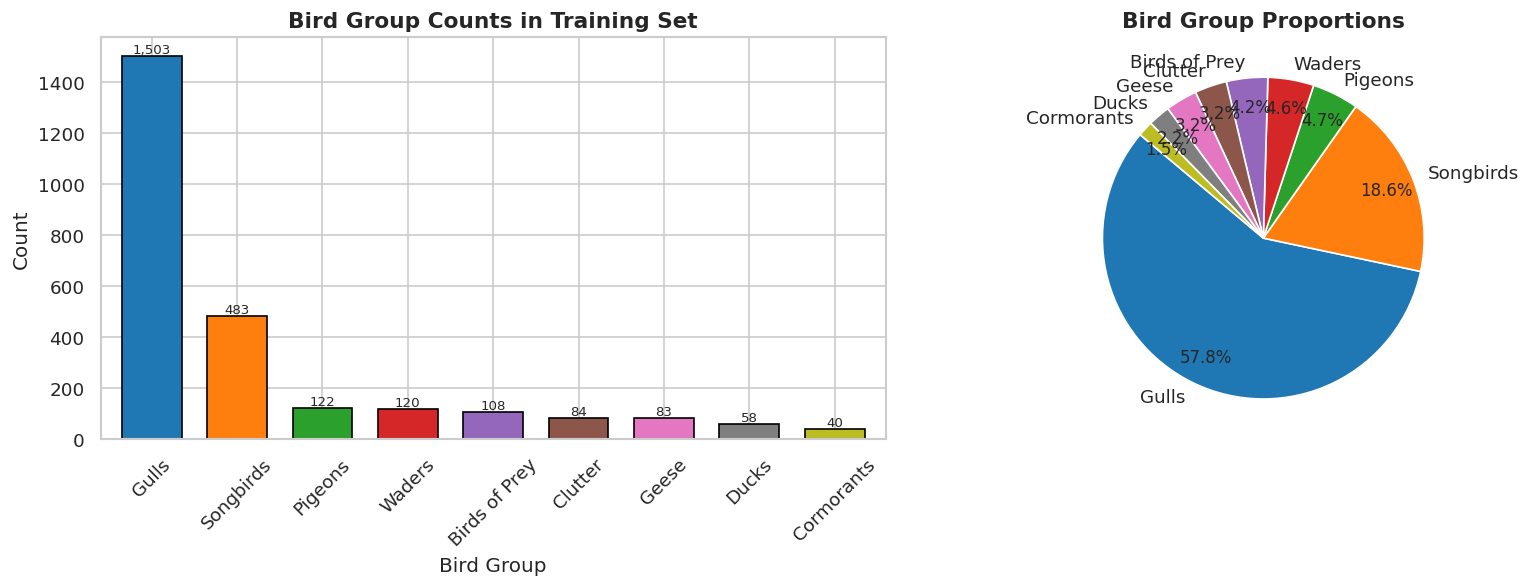

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = train["bird_group"].value_counts()
palette = sns.color_palette("tab10", len(counts))

counts.plot(kind="bar", ax=axes[0], color=palette, edgecolor="black", width=0.7)
axes[0].set_title("Bird Group Counts in Training Set", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Bird Group")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=8)

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=palette, startangle=140, pctdistance=0.82)
axes[1].set_title("Bird Group Proportions", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", bbox_inches="tight")
plt.show()


## Configuration

In [4]:
N_SPLITS   = 5
SEED       = 42
EARTH_R    = 6_371_000.0
EPS        = 1e-12
LAT_BIN    = 0.20
LON_BIN    = 0.20

# ── Model slots ────────────────────────────────────────────────────────────
# 0-3:  CB full-data (seeds 42,777 × variants A,B)
# 4-7:  CB gull-undersampled (seeds 42,777 × variants A,B)
# 8-9:  LGB full-data (seeds 42,777)
# 10:   Binary CB Cormorant vs Rest
# 11:   Binary CB Wader vs Rest

CB_SEEDS_FULL  = [42, 777]          # 2 seeds × 2 variants = 4 models
CB_SEEDS_BAL   = [42, 777]          # 4 more models on gull-undersampled data
CB_VARIANTS    = ["A", "B"]
LGB_SEEDS      = [42, 777]

M_CB_FULL  = len(CB_SEEDS_FULL) * len(CB_VARIANTS)   # 4
M_CB_BAL   = len(CB_SEEDS_BAL)  * len(CB_VARIANTS)   # 4
M_CB       = M_CB_FULL + M_CB_BAL                     # 8
M_LGB      = len(LGB_SEEDS)                           # 2
M_MC       = M_CB + M_LGB                             # 10 multiclass
M_TOTAL    = M_MC + 2                                 # 12 (+ 2 binary)

THREADS    = max(2, (os.cpu_count() or 4) - 1)

# ── Gull undersampling (v18 proven: 200 cap gave best LB=0.56) ─────────────
GULL_UNDERSAMPLE = 200   # cap Gulls at this many per fold in balanced models
                         # v19 tried 80 → Pigeon collapse, worse OOF → REVERTED

# ── Oversampling (proven in v15+) ──────────────────────────────────────────
OVERSAMPLE_MIN   = 150
OVERSAMPLE_NOISE = 0.01
OVERSAMPLE_SEED  = 2025

# ── Binary expert config (v20: improved) ───────────────────────────────────
# v17: alpha=0.05 fixed (tuned with v17 architecture)
# v20: tune alpha separately per class after Bayes; neg_ratio=2 (was 3)
#      auto_class_weights="Balanced" added to binary model
BINARY_NEG_RATIO   = 2              # v18=3; reducing gives more pos weight
BINARY_ALPHA_GRID  = [0.02, 0.05, 0.08, 0.12, 0.15, 0.20, 0.25, 0.30]

# ── Bias grids ─────────────────────────────────────────────────────────────
BIAS_GRID      = [-0.20,-0.15,-0.10,-0.05,0.0,0.05,0.10,0.15,0.20]
BIAS_GRID_WIDE = [-0.30,-0.20,-0.10,-0.05,0.0,0.05,0.10,0.20,0.30]  # for rank-0
BIAS_LL_TOL    = 0.0030
WEAKEST_K      = 3

# ── Bayes (v10 proven values — starting point for Optuna) ─────────────────
BETA_SIZECOND = 0.20
BETA_DENSITY  = 0.10
BETA_NIGHTMIG = 0.14
BETA_CTX      = 0.10

# ── Optuna beta search (v20 new: 200 trials, continuous bounds) ────────────
OPTUNA_N_TRIALS = 200
BETA_BOUNDS = {
    "size":  (0.0, 0.40),
    "den":   (0.0, 0.25),
    "mig":   (0.0, 0.25),
    "ctx":   (0.0, 0.25),
}

NE = np.deg2rad(45.0)
SW = np.deg2rad(225.0)
def circ_diff(a, b): return (a - b + np.pi) % (2*np.pi) - np.pi

print(f"CB full: {M_CB_FULL}  CB balanced: {M_CB_BAL}  LGB: {M_LGB}  Binary: 2  TOTAL: {M_TOTAL}")
print(f"Gull undersample cap: {GULL_UNDERSAMPLE} (ratio ~{GULL_UNDERSAMPLE//40}:1 vs Cormorant)")
print(f"Binary: neg_ratio={BINARY_NEG_RATIO}  alpha tuned per-class from {BINARY_ALPHA_GRID}")
print(f"BETA_NIGHTMIG: {BETA_NIGHTMIG} (v18 proven value)")
print(f"Optuna beta search: {OPTUNA_N_TRIALS} trials")
print(f"BIAS_GRID_WIDE defined: {BIAS_GRID_WIDE[0]} to {BIAS_GRID_WIDE[-1]}")


CB full: 4  CB balanced: 4  LGB: 2  Binary: 2  TOTAL: 12
Gull undersample cap: 200 (ratio ~5:1 vs Cormorant)
Binary: neg_ratio=2  alpha tuned per-class from [0.02, 0.05, 0.08, 0.12, 0.15, 0.2, 0.25, 0.3]
BETA_NIGHTMIG: 0.14 (v18 proven value)
Optuna beta search: 200 trials
BIAS_GRID_WIDE defined: -0.3 to 0.3


## Exploratory Data Analysis

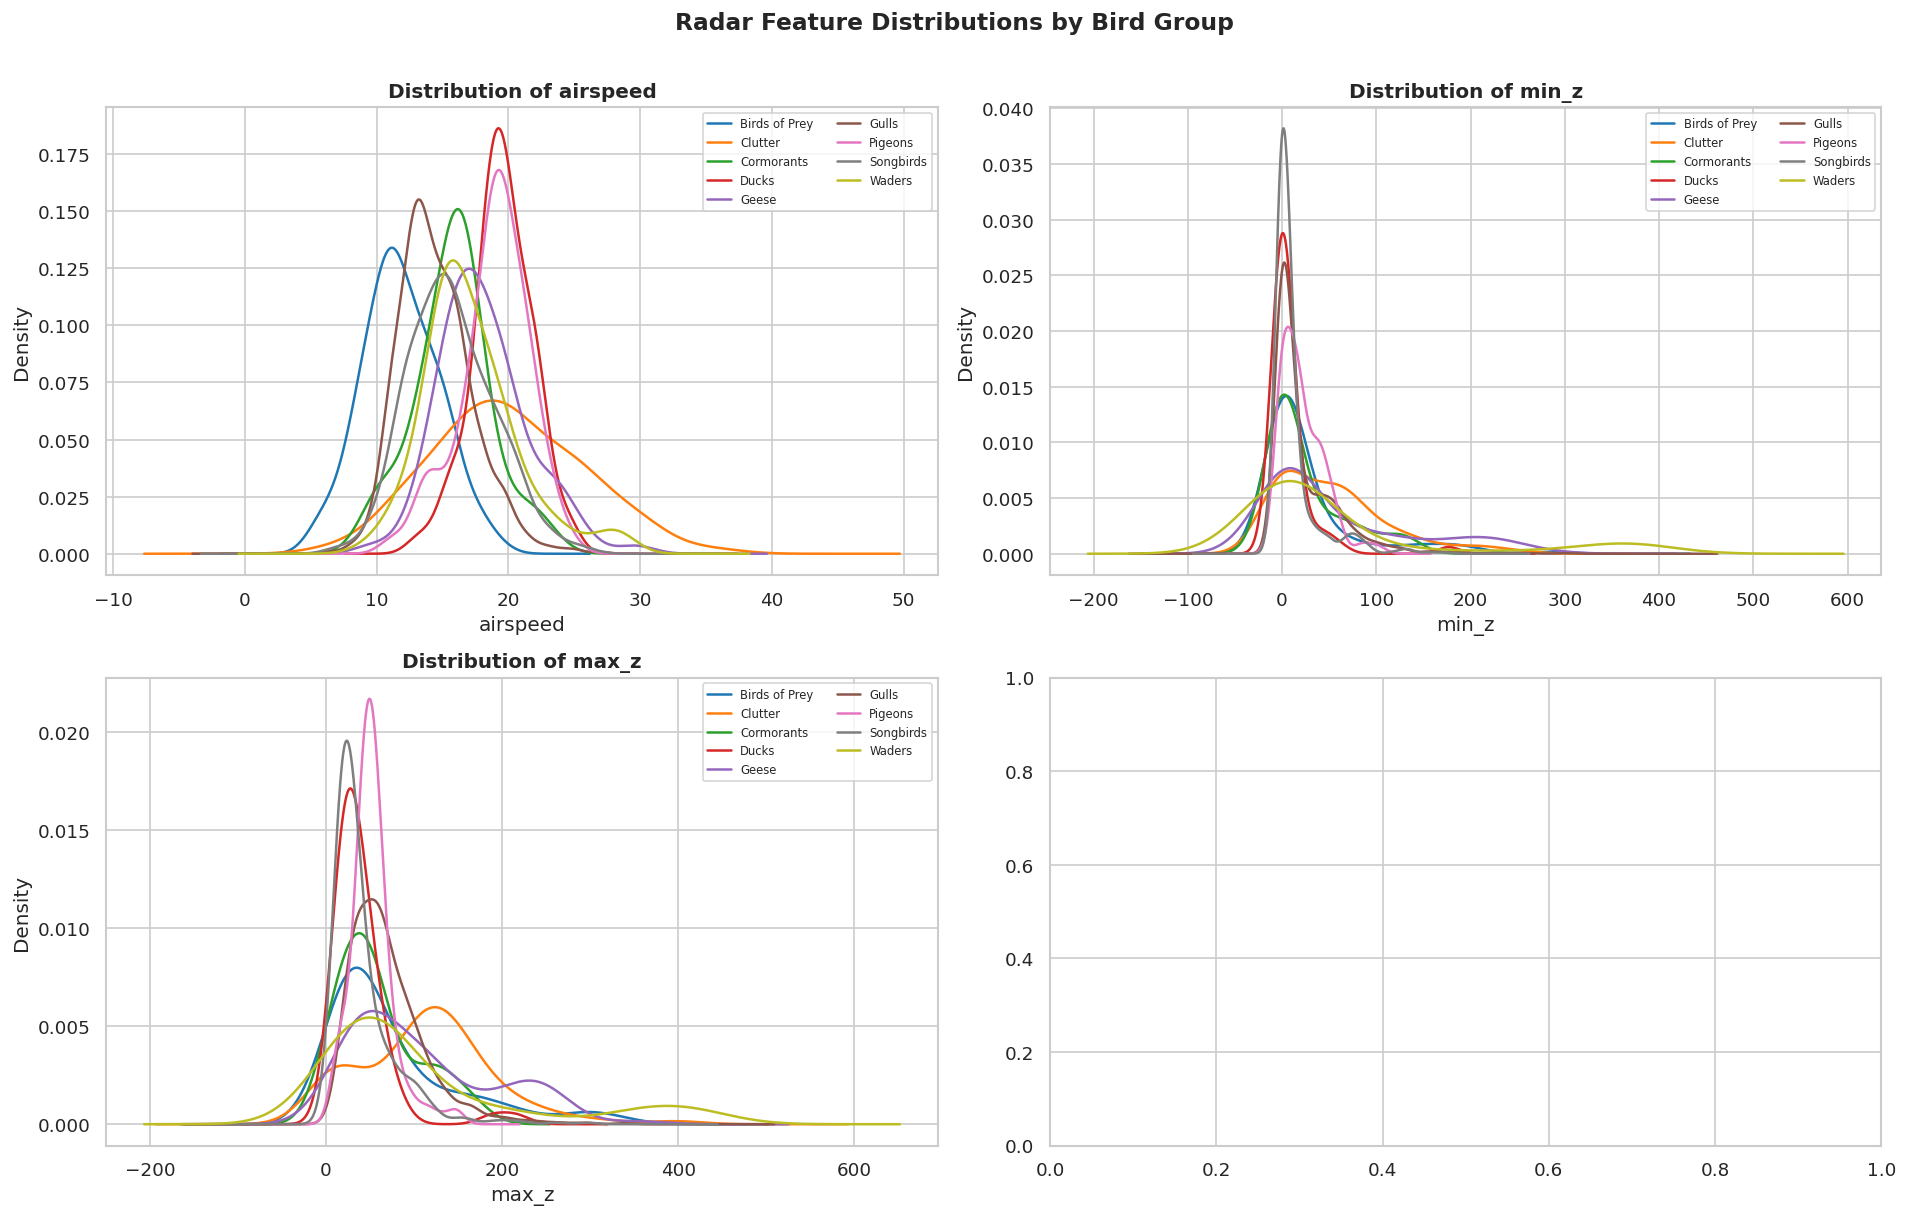

In [5]:
# Radar feature distributions by bird group
radar_cols = ["airspeed", "min_z", "max_z", "duration_s"]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(radar_cols):
    if col in train.columns:
        for group in sorted(train["bird_group"].unique()):
            vals = train.loc[train["bird_group"] == group, col].dropna()
            if len(vals) > 5:
                vals.plot.kde(ax=axes[i], label=group, linewidth=1.5)
        axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
        axes[i].set_xlabel(col)
        axes[i].legend(fontsize=7, ncol=2)

plt.suptitle("Radar Feature Distributions by Bird Group", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("feature_distributions.png", bbox_inches="tight")
plt.show()


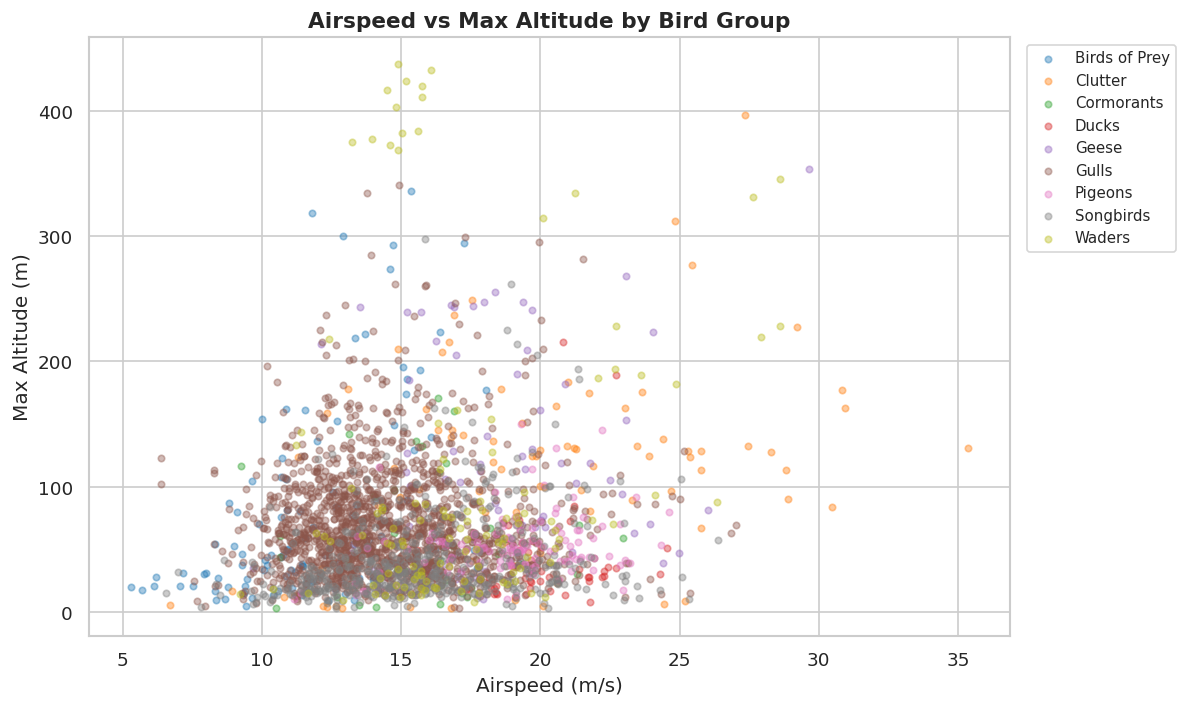

In [6]:
# Airspeed vs Altitude scatter
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette("tab10", train["bird_group"].nunique())

for i, group in enumerate(sorted(train["bird_group"].unique())):
    subset = train[train["bird_group"] == group]
    ax.scatter(subset["airspeed"], subset["max_z"],
               alpha=0.4, s=15, label=group, color=palette[i])

ax.set_xlabel("Airspeed (m/s)", fontsize=12)
ax.set_ylabel("Max Altitude (m)", fontsize=12)
ax.set_title("Airspeed vs Max Altitude by Bird Group", fontsize=13, fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("scatter_airspeed_altitude.png", bbox_inches="tight")
plt.show()


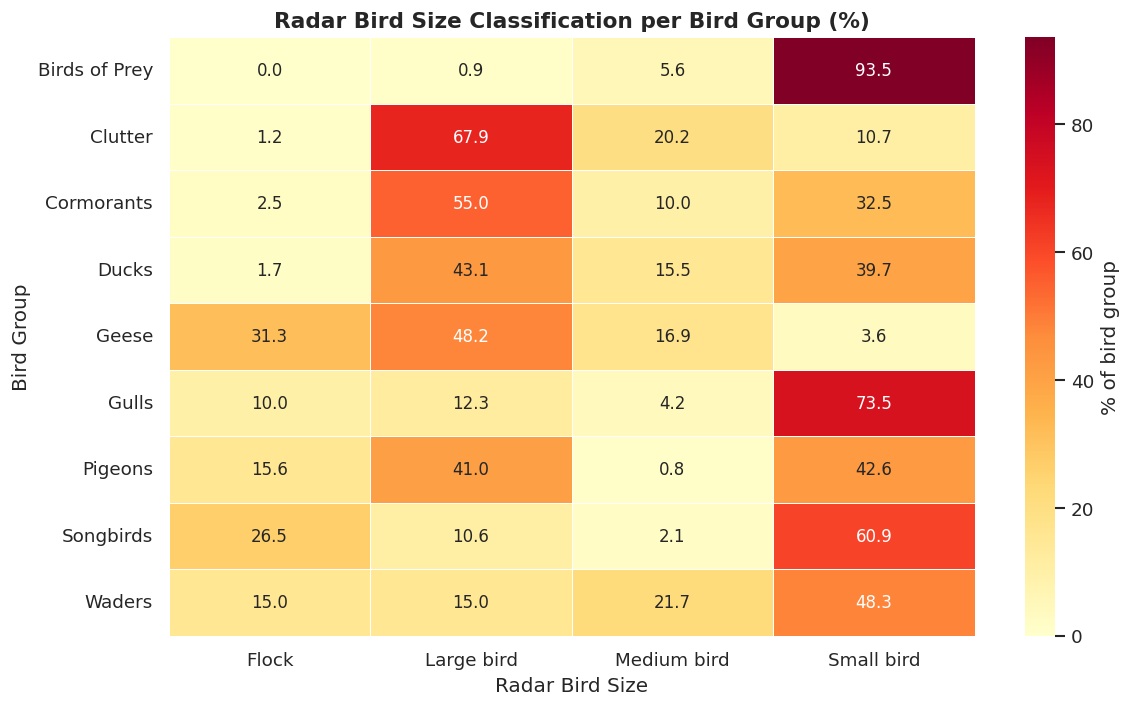

In [7]:
# Radar bird size heatmap
if "radar_bird_size" in train.columns:
    crosstab = pd.crosstab(train["bird_group"], train["radar_bird_size"].fillna("NA"))
    crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(crosstab_pct, annot=True, fmt=".1f", cmap="YlOrRd",
                cbar_kws={"label": "% of bird group"}, ax=ax, linewidths=0.5)
    ax.set_title("Radar Bird Size Classification per Bird Group (%)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Radar Bird Size")
    ax.set_ylabel("Bird Group")
    plt.tight_layout()
    plt.savefig("heatmap_radar_size.png", bbox_inches="tight")
    plt.show()


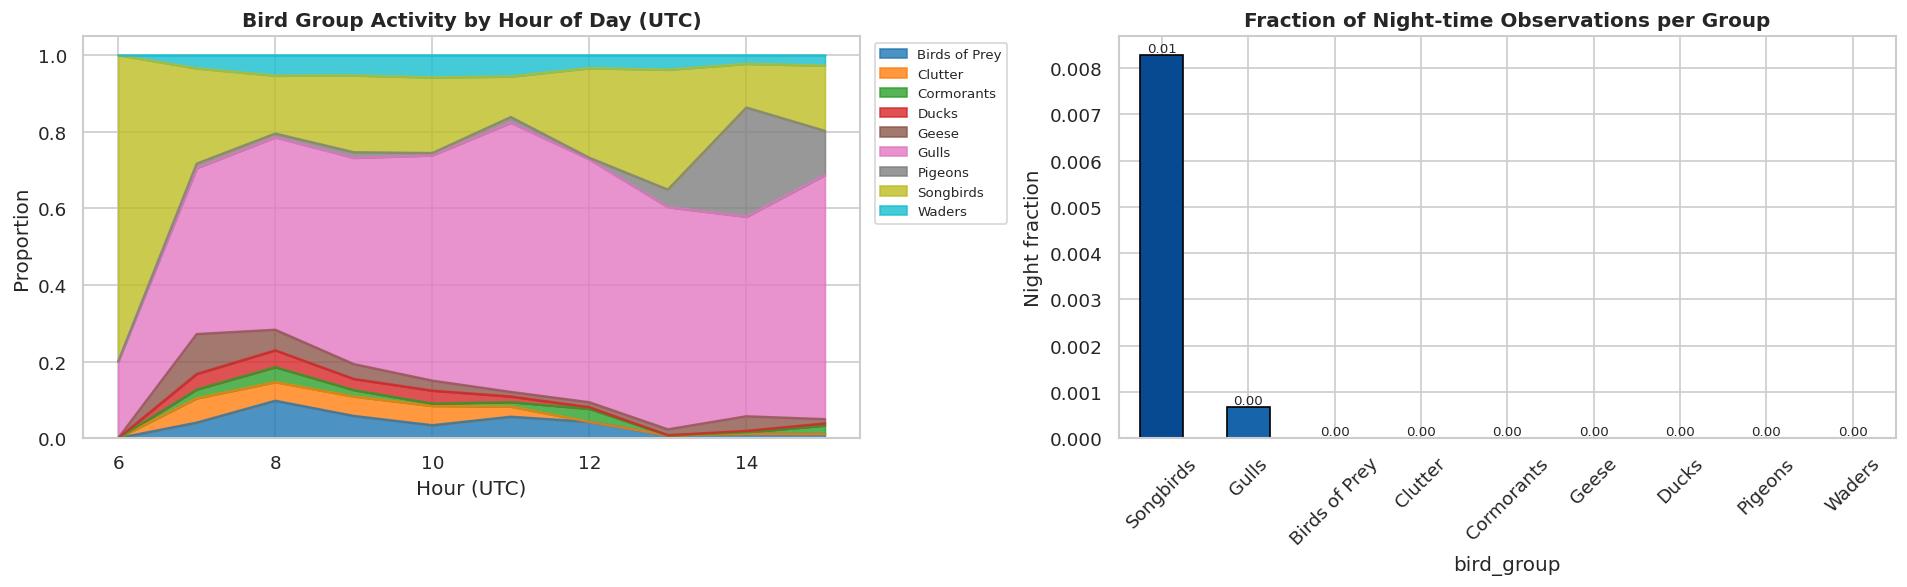

In [8]:
# Temporal patterns
train["_ts"]   = pd.to_datetime(train["timestamp_start_radar_utc"], utc=True, errors="coerce")
train["_hour"] = train["_ts"].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hour_group = train.groupby(["_hour", "bird_group"]).size().unstack(fill_value=0)
hour_group_pct = hour_group.div(hour_group.sum(axis=1), axis=0)
hour_group_pct.plot(kind="area", stacked=True, ax=axes[0], colormap="tab10", alpha=0.8)
axes[0].set_title("Bird Group Activity by Hour of Day (UTC)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Hour (UTC)")
axes[0].set_ylabel("Proportion")
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

train["_is_night"] = (train["_hour"] >= 18) | (train["_hour"] <= 6)
night_by_group = train.groupby("bird_group")["_is_night"].mean().sort_values(ascending=False)
night_by_group.plot(kind="bar", ax=axes[1],
                    color=sns.color_palette("Blues_r", len(night_by_group)), edgecolor="black")
axes[1].set_title("Fraction of Night-time Observations per Group", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Night fraction")
axes[1].tick_params(axis="x", rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("temporal_patterns.png", bbox_inches="tight")
plt.show()


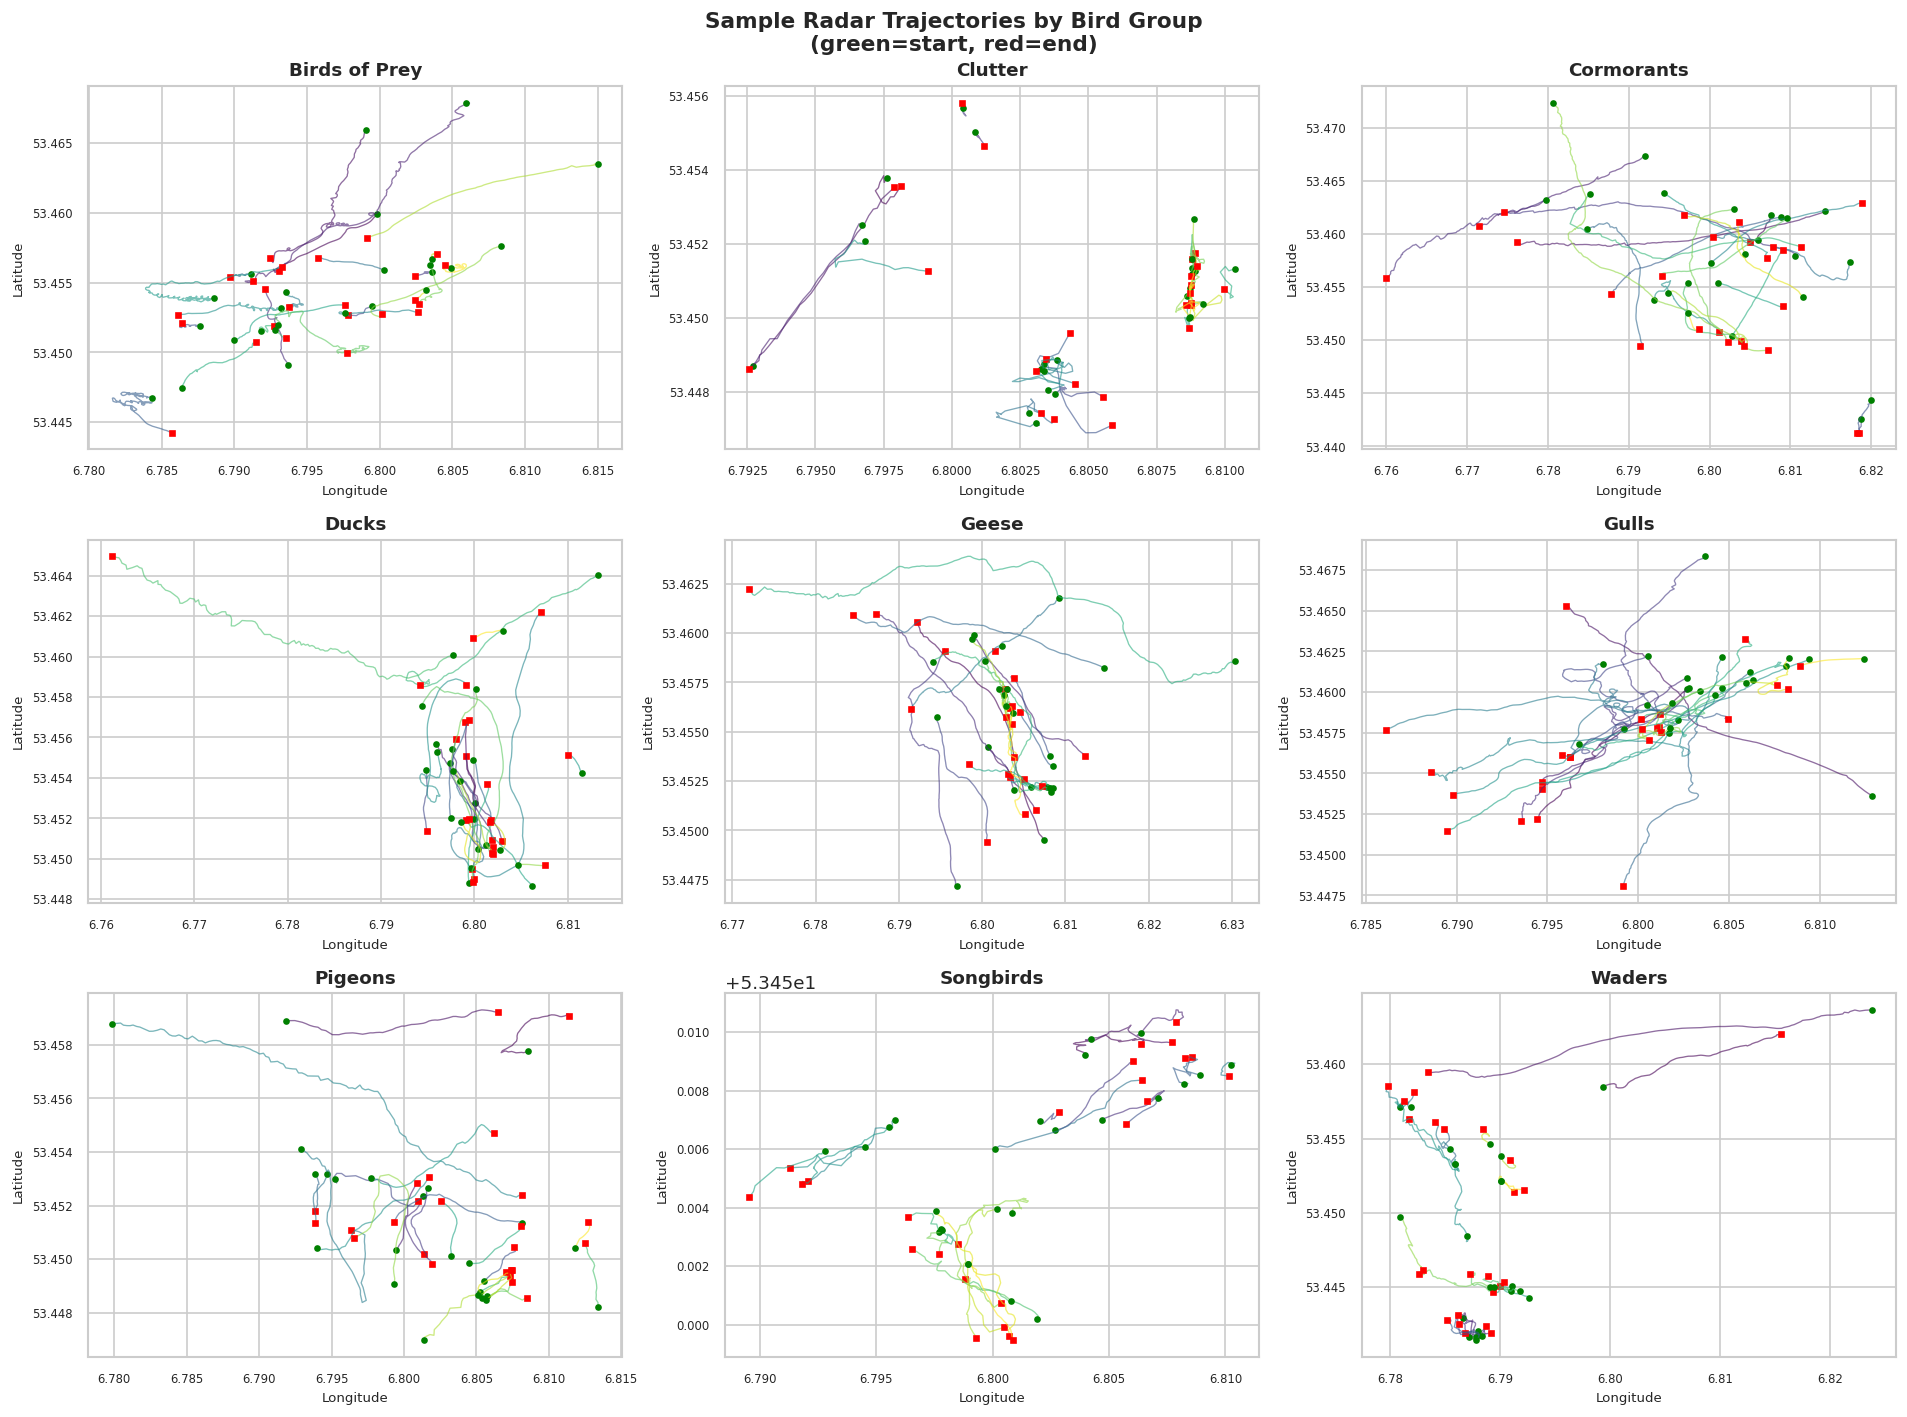

In [9]:
# Sample trajectories by bird group
groups_sorted = sorted(train["bird_group"].unique())
n_groups = len(groups_sorted)
ncols = 3
nrows = int(np.ceil(n_groups / ncols))

@lru_cache(maxsize=80000)
def _parse_wkb_eda(s):
    if not s or s in ("nan","None",""): return np.array([]),np.array([])
    try:
        geom = wkb.loads(binascii.unhexlify(s))
        c = np.asarray(geom.coords, dtype=np.float64)
        if c.ndim!=2 or c.shape[0]==0: return np.array([]),np.array([])
        return c[:,0], c[:,1]
    except: return np.array([]),np.array([])

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()
for idx, group in enumerate(groups_sorted):
    ax = axes[idx]
    subset = train[train["bird_group"] == group].head(25)
    colors = cm.viridis(np.linspace(0, 1, len(subset)))
    for i, (_, row) in enumerate(subset.iterrows()):
        lon, lat = _parse_wkb_eda(str(row.get("trajectory","")))
        if lon.size >= 2:
            ax.plot(lon, lat, alpha=0.6, linewidth=0.8, color=colors[i])
            ax.plot(lon[0], lat[0], "go", markersize=3)
            ax.plot(lon[-1], lat[-1], "rs", markersize=3)
    ax.set_title(group, fontsize=11, fontweight="bold")
    ax.set_xlabel("Longitude", fontsize=8)
    ax.set_ylabel("Latitude", fontsize=8)
    ax.tick_params(labelsize=7)
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Sample Radar Trajectories by Bird Group\n(green=start, red=end)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("trajectory_maps.png", bbox_inches="tight")
plt.show()


## Feature Engineering

Full trajectory featurisation: kinematics, geometry, altitude bands, RCS statistics, temporal features, spatial cell IDs, and season interactions.

In [10]:
@lru_cache(maxsize=80000)
def _parse_wkb(s):
    if not s or s in ("nan","None",""):
        return np.array([]),np.array([]),np.array([]),np.array([])
    try:
        geom   = wkb.loads(binascii.unhexlify(s))
        coords = np.asarray(geom.coords, dtype=np.float64)
        if coords.ndim != 2 or coords.shape[0] == 0:
            return np.array([]),np.array([]),np.array([]),np.array([])
        if coords.shape[1] == 3:
            lon, lat, z = coords[:,0],coords[:,1],coords[:,2]
            rcs = np.full_like(z, np.nan)
        else:
            lon,lat,z,rcs = coords[:,0],coords[:,1],coords[:,2],coords[:,3]
        return lon,lat,z,rcs
    except:
        return np.array([]),np.array([]),np.array([]),np.array([])

def parse_traj(s):
    return _parse_wkb(str(s)) if pd.notna(s) else (np.array([]),)*4

@lru_cache(maxsize=80000)
def _parse_times(s):
    if not s or s in ("nan","None",""):
        return np.array([],dtype=np.float64)
    try:
        return np.array(ast.literal_eval(s),dtype=np.float64)
    except:
        return np.array([],dtype=np.float64)

def parse_times(t):
    if isinstance(t,(list,np.ndarray)):
        return np.asarray(t,dtype=np.float64)
    return _parse_times(str(t)) if pd.notna(t) else np.array([],dtype=np.float64)

def haversine_m(lat1,lon1,lat2,lon2):
    lat1=np.deg2rad(lat1);lon1=np.deg2rad(lon1)
    lat2=np.deg2rad(lat2);lon2=np.deg2rad(lon2)
    a=(np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2)
    return 2*EARTH_R*np.arcsin(np.sqrt(np.clip(a,0,1)))

def bearing_rad(lat1,lon1,lat2,lon2):
    lat1=np.deg2rad(lat1);lat2=np.deg2rad(lat2);dlon=np.deg2rad(lon2-lon1)
    y=np.sin(dlon)*np.cos(lat2)
    x=np.cos(lat1)*np.sin(lat2)-np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
    return np.arctan2(y,x)

def ang_diff(a): return (a+np.pi)%(2*np.pi)-np.pi

def lonlat_to_xy(lon,lat):
    if lon.size==0: return np.array([]),np.array([])
    lat0=np.deg2rad(np.nanmean(lat))
    return EARTH_R*np.deg2rad(lon)*np.cos(lat0), EARTH_R*np.deg2rad(lat)

def safe_stats(arr, pfx):
    nan_d={f"{pfx}_{k}":np.nan for k in ["mean","std","max","min","p10","p25","p50","p75","p90","mad","cv","iqr"]}
    if arr is None or len(arr)==0: return nan_d
    a=np.asarray(arr,dtype=np.float64); a=a[np.isfinite(a)]
    if len(a)==0: return nan_d
    mn=float(np.mean(a));sd=float(np.std(a));med=float(np.median(a))
    p10,p25,p50,p75,p90=np.percentile(a,[10,25,50,75,90])
    return {f"{pfx}_mean":mn,f"{pfx}_std":sd,f"{pfx}_max":float(a.max()),
            f"{pfx}_min":float(a.min()),f"{pfx}_p10":float(p10),f"{pfx}_p25":float(p25),
            f"{pfx}_p50":float(p50),f"{pfx}_p75":float(p75),f"{pfx}_p90":float(p90),
            f"{pfx}_mad":float(np.median(np.abs(a-med))),
            f"{pfx}_cv":float(sd/(abs(mn)+1e-6)),f"{pfx}_iqr":float(p75-p25)}

def circle_fit(x,y):
    x=np.asarray(x,dtype=np.float64);y=np.asarray(y,dtype=np.float64)
    m=np.isfinite(x)&np.isfinite(y);x,y=x[m],y[m]
    if x.size<6: return np.nan,np.nan
    A=np.column_stack([2*x,2*y,np.ones_like(x)]);b=x**2+y**2
    try:
        sol,*_=np.linalg.lstsq(A,b,rcond=None);cx,cy,c=sol
        r=math.sqrt(max(c+cx**2+cy**2,0.0))
        rmse=float(np.sqrt(np.mean((np.sqrt((x-cx)**2+(y-cy)**2)-r)**2)))
        return float(r),rmse
    except: return np.nan,np.nan

def _night_id(ts):
    if pd.isna(ts): return "NA"
    return (ts-pd.Timedelta(hours=12)).date().isoformat()

print("Geo helpers defined ✓")


Geo helpers defined ✓


In [11]:
def featurize_row(row):
    out = {}
    lon,lat,z,rcs = parse_traj(row.get("trajectory"))
    t = parse_times(row.get("trajectory_time"))
    if t.size and lon.size==t.size:
        order=np.argsort(t);t=t[order];lon=lon[order];lat=lat[order];z=z[order];rcs=rcs[order]
    n=int(t.size); out["n_points"]=n
    dur=float(t[-1]-t[0]) if n>=2 else 0.0
    out["duration_s"]=dur; out["duration_log1p"]=float(np.log1p(max(dur,0)))
    if n:
        out["lon_mean"]=float(np.nanmean(lon)); out["lat_mean"]=float(np.nanmean(lat))
        out["lon_std"]=float(np.nanstd(lon));   out["lat_std"]=float(np.nanstd(lat))
        out["lon_range"]=float(np.nanmax(lon)-np.nanmin(lon))
        out["lat_range"]=float(np.nanmax(lat)-np.nanmin(lat))
    else:
        for k in ["lon_mean","lat_mean","lon_std","lat_std","lon_range","lat_range"]: out[k]=np.nan
    out.update(safe_stats(z,"z")); out.update(safe_stats(rcs,"rcs"))
    total_dist=0.0; disp=0.0
    if n>=2:
        dt=np.clip(np.diff(t).astype(np.float64),1e-3,None)
        dxy=haversine_m(lat[:-1],lon[:-1],lat[1:],lon[1:]).astype(np.float64)
        dz=np.diff(z).astype(np.float64); spd=dxy/dt; vspd=dz/dt
        brg=bearing_rad(lat[:-1],lon[:-1],lat[1:],lon[1:]).astype(np.float64)
        turn_ang=ang_diff(np.diff(brg)) if brg.size>=2 else np.array([])
        turn_rate=(turn_ang/np.clip(dt[1:],1e-3,None)) if turn_ang.size else np.array([])
        total_dist=float(np.nansum(dxy)); disp=float(haversine_m(lat[0],lon[0],lat[-1],lon[-1]))
        out["total_dist_m"]=total_dist; out["displacement_m"]=disp
        out["straightness"]=disp/max(total_dist,1e-6); out["sinuosity"]=total_dist/max(disp,1e-6)
        for nm,arr in [("dt",dt),("segdist",dxy),("spd",spd),("vspd",vspd),
                       ("turn_rate",turn_rate),("turn_ang",turn_ang)]:
            out.update(safe_stats(arr,nm))
        out["total_ascent_m"]=float(np.nansum(np.clip(dz,0,None)))
        out["total_descent_m"]=float(np.nansum(np.clip(-dz,0,None)))
        out["start_z"]=float(z[0]); out["end_z"]=float(z[-1]); out["delta_z"]=float(z[-1]-z[0])
        nb=bearing_rad(lat[0],lon[0],lat[-1],lon[-1])
        out["net_brg_sin"]=float(np.sin(nb)); out["net_brg_cos"]=float(np.cos(nb))
        acc=(np.diff(spd)/np.clip(dt[1:],1e-3,None)) if spd.size>=2 else np.array([])
        jerk=(np.diff(acc)/np.clip(dt[2:],1e-3,None)) if acc.size>=2 else np.array([])
        vacc=(np.diff(vspd)/np.clip(dt[1:],1e-3,None)) if vspd.size>=2 else np.array([])
        for nm,arr in [("acc",acc),("jerk",jerk),("vacc",vacc)]: out.update(safe_stats(arr,nm))
        tat=float(np.nansum(np.abs(turn_ang))) if turn_ang.size else 0.0
        out["turn_total_abs_rad"]=tat; out["turn_loops_est"]=tat/(2*np.pi+1e-9)
        out["brg_resultant"]=(float(np.sqrt(np.nanmean(np.sin(brg))**2+np.nanmean(np.cos(brg))**2))
                               if brg.size else np.nan)
        x,y=lonlat_to_xy(lon,lat); xm,ym=np.nanmean(x),np.nanmean(y); xc,yc=x-xm,y-ym
        out["radius_gyr_m"]=float(np.sqrt(np.nanmean(xc**2+yc**2))) if x.size else np.nan
        out["bbox_area_m2"]=(float((np.nanmax(x)-np.nanmin(x))*(np.nanmax(y)-np.nanmin(y)))
                             if x.size else np.nan)
        if x.size>=3:
            try:
                hull=MultiPoint(np.column_stack([x,y])).convex_hull
                out["hull_area_m2"]=float(hull.area); out["hull_perim_m"]=float(hull.length)
                out["hull_compact"]=float(4*np.pi*hull.area/(hull.length**2+1e-12))
            except: out["hull_area_m2"]=out["hull_perim_m"]=out["hull_compact"]=np.nan
        else: out["hull_area_m2"]=out["hull_perim_m"]=out["hull_compact"]=np.nan
        if n>=3:
            try:
                ev=np.sort(np.linalg.eigvalsh(np.cov(np.c_[x,y].T)))[::-1]
                out["pca_lin"]=float(ev[0]/(ev.sum()+1e-12))
            except: out["pca_lin"]=np.nan
        else: out["pca_lin"]=np.nan
        r_fit,rmse_fit=circle_fit(xc,yc)
        out["circle_r_m"]=r_fit; out["circle_rmse_m"]=rmse_fit
        out["circle_rel_rmse"]=((rmse_fit/(r_fit+1e-9))
                                 if (np.isfinite(r_fit) and np.isfinite(rmse_fit)) else np.nan)
        if spd.size:
            out["slow_frac"]=float(np.mean(spd<2.0))
            out["spd_gt5_frac"]=float(np.mean(spd>5.0))
            out["spd_gt15_frac"]=float(np.mean(spd>15.0))
            out["spd_gt30_frac"]=float(np.mean(spd>30.0))
            thr90=np.nanpercentile(spd,90); out["top10_spd_mean"]=float(np.nanmean(spd[spd>=thr90]))
        else:
            for k in ["slow_frac","spd_gt5_frac","spd_gt15_frac","spd_gt30_frac","top10_spd_mean"]:
                out[k]=np.nan
        out["tiny_move_frac"]=float(np.mean(dxy<1.0)) if dxy.size else np.nan
        out["sharp_turn_frac"]=(float(np.mean(np.abs(turn_rate)>0.15)) if turn_rate.size else np.nan)
        if x.size:
            gx=np.floor(x/20.0).astype(int); gy=np.floor(y/20.0).astype(int)
            out["grid20_unique_ratio"]=float(len(set(zip(gx,gy)))/max(n,1))
        else: out["grid20_unique_ratio"]=np.nan
        msk=np.isfinite(t)&np.isfinite(z)
        if msk.sum()>=3:
            try: out["z_slope"]=float(np.polyfit(t[msk],z[msk],1)[0])
            except: out["z_slope"]=np.nan
        else: out["z_slope"]=np.nan
        sp=max(1,n//3)
        out.update(safe_stats(spd[:sp],"early_spd")); out.update(safe_stats(spd[-sp:],"late_spd"))
        em=float(np.nanmean(spd[:sp])); lm=float(np.nanmean(spd[-sp:]))
        out["spd_trend"]=lm-em; out["spd_trend_ratio"]=lm/(em+1e-6)
        denom=max(dur,1.0)
        out["points_per_s"]=float(n/denom); out["dist_per_s"]=float(total_dist/denom)
        out["disp_per_s"]=float(disp/denom)
        out["dir_to_NE"]=float(np.cos(circ_diff(nb,NE))); out["dir_to_SW"]=float(np.cos(circ_diff(nb,SW)))
    else:
        for pfx in ["dt","segdist","spd","vspd","turn_rate","turn_ang","acc","jerk","vacc",
                    "early_spd","late_spd"]:
            out.update(safe_stats(None,pfx))
        for k in ["total_dist_m","displacement_m","straightness","sinuosity","total_ascent_m",
                  "total_descent_m","start_z","end_z","delta_z","net_brg_sin","net_brg_cos",
                  "radius_gyr_m","bbox_area_m2","hull_area_m2","hull_perim_m","hull_compact","pca_lin",
                  "circle_r_m","circle_rmse_m","circle_rel_rmse","turn_total_abs_rad","turn_loops_est",
                  "brg_resultant","slow_frac","spd_gt5_frac","spd_gt15_frac","spd_gt30_frac",
                  "top10_spd_mean","tiny_move_frac","sharp_turn_frac","grid20_unique_ratio","z_slope",
                  "spd_trend","spd_trend_ratio","points_per_s","dist_per_s","disp_per_s",
                  "dir_to_NE","dir_to_SW"]:
            out[k]=np.nan
    zv=z[np.isfinite(z)] if z.size else np.array([])
    if zv.size:
        out["z_q10"]=float(np.percentile(zv,10)); out["z_q90"]=float(np.percentile(zv,90))
        out["z_iqr"]=float(np.percentile(zv,75)-np.percentile(zv,25))
        for thr,nm in [(200,"200"),(500,"500"),(1000,"1000"),(2000,"2000")]:
            out[f"frac_z_lt_{nm}"]=float(np.mean(zv<thr))
        out["frac_z_2k_3k"]=float(np.mean((zv>=2000)&(zv<3000)))
        out["frac_z_gt_3000"]=float(np.mean(zv>=3000))
    else:
        for k in ["z_q10","z_q90","z_iqr","frac_z_lt_200","frac_z_lt_500","frac_z_lt_1000",
                  "frac_z_lt_2000","frac_z_2k_3k","frac_z_gt_3000"]:
            out[k]=0.0
    rv=rcs[np.isfinite(rcs)] if rcs.size else np.array([])
    if rv.size:
        r_p50=float(np.percentile(rv,50)); r_p90=float(np.percentile(rv,90))
        r_p95=float(np.percentile(rv,95))
        out["rcs_spike_p90p50"]=r_p90-r_p50
        out["rcs_spike_p90p10"]=r_p90-float(np.percentile(rv,10))
        out["rcs_cv"]=float(np.std(rv)/(abs(np.mean(rv))+1e-6))
        out["rcs_outlier_frac"]=float(np.mean(rv>r_p95))
        out["rcs_median"]=r_p50; out["rcs_p90"]=r_p90
    else:
        out["rcs_spike_p90p50"]=out["rcs_spike_p90p10"]=0.0
        out["rcs_cv"]=out["rcs_outlier_frac"]=0.0
        out["rcs_median"]=out["rcs_p90"]=np.nan
    out["rain_clutter_score"]=float(np.clip(0.6*out["rcs_spike_p90p50"]+0.4*out["rcs_outlier_frac"],-5,5))
    low_alt=out["frac_z_lt_200"]
    low_motion=float((disp<200) or (total_dist<500) or (out.get("dist_per_s",10) or 10)<5) if n>=2 else 0.0
    straight=float(out.get("straightness",0) or 0)
    out["clutter_risk"]=float(np.clip(low_alt*(0.5+0.5*low_motion)*(1-straight),0,1))
    out["airspeed"]=float(row.get("airspeed") or 0) if pd.notna(row.get("airspeed")) else 0.0
    out["min_z"]=float(row.get("min_z") or 0) if pd.notna(row.get("min_z")) else 0.0
    out["max_z"]=float(row.get("max_z") or 0) if pd.notna(row.get("max_z")) else 0.0
    out["alt_range"]=float(out["max_z"]-out["min_z"]); out["alt_mid"]=float(0.5*(out["max_z"]+out["min_z"]))
    sr=str(row.get("radar_bird_size","NA") or "NA").strip()
    out["radar_bird_size"]=sr
    out["is_small"]=float(sr=="Small bird"); out["is_flock"]=float(sr=="Flock")
    out["z_mean_minus_alt_mid"]=float(out.get("z_mean",0) or 0)-out["alt_mid"]
    ts=pd.to_datetime(row.get("timestamp_start_radar_utc"),utc=True,errors="coerce")
    if pd.notna(ts):
        h=int(ts.hour); doy=int(ts.dayofyear)
        out["hour"]=h; out["dayofyear"]=doy; out["month"]=int(ts.month)
        out["hour_sin"]=float(np.sin(2*np.pi*h/24)); out["hour_cos"]=float(np.cos(2*np.pi*h/24))
        out["doy_sin"]=float(np.sin(2*np.pi*doy/365)); out["doy_cos"]=float(np.cos(2*np.pi*doy/365))
        out["night_id"]=_night_id(ts); out["is_night"]=int(h>=18 or h<=6)
    else:
        out["hour"]=out["dayofyear"]=out["month"]=-1
        out["hour_sin"]=out["hour_cos"]=out["doy_sin"]=out["doy_cos"]=0.0
        out["night_id"]="NA"; out["is_night"]=0
    out["is_spring"]=int(out["month"] in [3,4,5]); out["is_autumn"]=int(out["month"] in [9,10,11])
    try:
        t0=pd.to_datetime(row["timestamp_start_radar_utc"],utc=True)
        t1=pd.to_datetime(row["timestamp_end_radar_utc"],utc=True)
        out["track_dur_s"]=float((t1-t0).total_seconds())
    except: out["track_dur_s"]=np.nan
    latm=out.get("lat_mean",np.nan); lonm=out.get("lon_mean",np.nan)
    if np.isfinite(latm) and np.isfinite(lonm):
        lb=float(np.round(latm/LAT_BIN)*LAT_BIN); loB=float(np.round(lonm/LON_BIN)*LON_BIN)
        out["cell_id"]=f"{lb:.2f}_{loB:.2f}"
    else: out["cell_id"]="NA"
    out["cell_night_id"]=f'{out["cell_id"]}_{out["night_id"]}'
    out["autumn_low_alt"]=out["is_autumn"]*out["frac_z_lt_1000"]
    out["spring_high_alt"]=out["is_spring"]*out["frac_z_2k_3k"]
    out["autumn_dir_NE"]=out["is_autumn"]*float(out.get("dir_to_NE") or 0)
    out["spring_dir_SW"]=out["is_spring"]*float(out.get("dir_to_SW") or 0)
    out["night_migrant"]=out["is_night"]*float(out.get("spd_gt5_frac") or 0)

    # ═══════════════════════════════════════════════════════════════════════
    # v17 NEW FEATURES — derived from class boxplots (competition viz tool)
    # 
    # Key findings from boxplots:
    #   Cormorant: max_z≈60m, avg_rcs≈-25, n_birds 10-80
    #   Wader:     min_z>10m, max_z<80m, slow, small flock
    #   Gull:      max_z≈100m, avg_rcs≈-23 — ambiguous middle
    #   Geese:     n_birds>50, airspeed>18, avg_rcs>-20, max_z>150
    #   Ducks:     fastest airspeed(≈23), low alt
    #   Pigeons:   airspeed≈20, short duration, small RCS
    #   BoP:       n_birds<5 (solo), high max_z
    #   Clutter:   avg_rcs>-20, high altitude
    #   Songbirds: avg_rcs<-26, low max_z
    # ═══════════════════════════════════════════════════════════════════════

    # ── DIRECT BOXPLOT FEATURES ───────────────────────────────────────────
    # avg_rcs and n_birds are raw columns — extract them directly if available
    airspeed_v = float(out.get("airspeed", 0.0) or 0.0)
    n_birds_v  = float(out.get("n_birds",  0.0) or 0.0)

    # From the featurize_row inputs — use z and rcs arrays directly
    zv = z[np.isfinite(z)] if z.size else np.array([0.0])
    rv = rcs[np.isfinite(rcs)] if rcs.size else np.array([-25.0])

    max_z_v    = float(zv.max()) if zv.size else 0.0
    min_z_v    = float(zv.min()) if zv.size else 0.0
    avg_rcs_v  = float(rv.mean()) if rv.size else -25.0
    dur_v      = float(out.get("duration_s", 0.0) or 0.0)   # v21 BUG FIX: was "duration" (always 0)
    st_v       = float(out.get("straightness", 0.5) or 0.5)
    z_cv_v     = float(out.get("z_cv", 1.0) or 1.0)

    # ── GEESE DISCRIMINANT (n_birds>50, fast, large RCS, high altitude) ───
    out["geese_score"] = float(
        (n_birds_v > 50) * 1.0 +
        (airspeed_v > 18) * 0.5 +
        (avg_rcs_v > -21) * 0.5 +
        (max_z_v > 100) * 0.3 +
        (dur_v > 100) * 0.2
    )
    out["is_large_flock"] = float(n_birds_v > 60)
    out["n_birds_gt_100"] = float(n_birds_v > 100)

    # ── PIGEON / DUCK DISCRIMINANT (fast airspeed) ────────────────────────
    out["is_fast_mover"]    = float(airspeed_v > 19)    # Pigeons & Ducks
    out["is_very_fast"]     = float(airspeed_v > 22)    # Ducks especially
    out["pigeon_score"] = float(
        (airspeed_v > 18) * 1.0 +
        (dur_v < 80) * 0.5 +
        (avg_rcs_v < -24) * 0.3
    )
    # ── DUCK SIGNATURE (v21 NEW: 60% of Ducks vs 8% of others) ──────────────
    # Duck: fastest flier (airspeed median=19.5) + very low altitude (min_z=0)
    # + low max_z (28m) — unique combo from user analysis
    out["duck_signature"]  = float(airspeed_v > 18 and min_z_v < 5)    # 60% Ducks vs 8% others
    out["duck_fast_low"]   = float(airspeed_v > 18 and max_z_v < 50)   # fast + low ceiling
    out["duck_score"] = float(
        (airspeed_v > 18) * 1.0 +
        (min_z_v < 5) * 0.8 +           # very low to ground
        (max_z_v < 50) * 0.5 +          # low ceiling
        (avg_rcs_v < -23) * 0.3         # medium-small bird RCS
    )

    # ── BIRDS OF PREY DISCRIMINANT (solo, high-soaring) ───────────────────
    out["is_solo_bird"]  = float(n_birds_v < 5)
    out["is_small_flock"]= float(n_birds_v < 10)
    out["bop_score"] = float(
        (n_birds_v < 6) * 1.0 +
        (airspeed_v < 13) * 1.2 +   # v21: BOP median=11.5, Gull=14.1 — STRONG separator
        (airspeed_v < 12) * 0.5 +   # v21: extra weight for very slow fliers
        (max_z_v > 40) * 0.3 +      # soaring higher than Songbirds
        (dur_v > 40) * 0.3           # longer tracks (not short like Songbirds)
    )
    out["bop_slow_flier"]   = float(airspeed_v < 13)   # v21: BOP key feature
    out["bop_very_slow"]    = float(airspeed_v < 11)   # v21: extremely slow

    # ── SONGBIRD DISCRIMINANT (v21 NEW — Gull/Songbird is top confusion) ──────
    # Key separators (from data analysis):
    # - Duration: Songbird=28s vs Gull=61s → ratio 2.2x
    # - max_z: Songbird=29m vs Gull=61m → ratio 2.1x
    # - Combined: 4.3x separation
    # - n_birds: Songbirds often in flocks (n>=3: 57% vs Gull: 27%)
    out["songbird_low_maxz"]  = float(max_z_v < 40)          # 66% Songbirds vs 25% Gulls
    out["songbird_short_dur"] = float(dur_v < 40)             # 73% Songbirds vs 29% Gulls
    out["songbird_score"] = float(
        (max_z_v < 40) * 1.2 +          # strong: Songbird flies low
        (dur_v < 40) * 1.0 +             # strong: short track
        (n_birds_v >= 3) * 0.5 +         # medium: flock indicator
        (airspeed_v > 13) * 0.3 +        # medium: fast (not BoP)
        (avg_rcs_v < -25) * 0.4          # medium: small radar cross section
    )
    out["max_z_x_duration"]  = max_z_v * dur_v   # v21: 4.3x Gull/Songbird separator
    out["gull_vs_song_dur"]  = float(dur_v > 50)  # 66% Gulls vs 27% Songbirds

    # ── CLUTTER DISCRIMINANT (high RCS, high altitude) ────────────────────
    out["rcs_is_high"]    = float(avg_rcs_v > -20)   # Clutter/Geese
    out["rcs_is_low"]     = float(avg_rcs_v < -26)   # Songbirds/Pigeons
    out["clutter_score"]  = float(
        (avg_rcs_v > -20) * 1.0 +
        (min_z_v > 50) * 0.5
    )

    # ── CORMORANT DISCRIMINANT (KEY FINDING FROM BOXPLOTS) ────────────────
    # Cormorant: max_z≈60 (low ceiling), avg_rcs≈-25, n_birds 10-80
    # Gull:      max_z≈100, avg_rcs≈-23 — higher and brighter
    # The difference: Cormorant max_z is ~40m LOWER than Gull
    out["corm_maxz_range"]   = float(max_z_v < 80)    # Cormorant ceiling
    out["corm_rcs_range"]    = float(-28 < avg_rcs_v < -21)  # Cormorant RCS window
    out["corm_not_fast"]     = float(airspeed_v < 17)  # Cormorant not fast like Geese
    out["cormorant_score_v2"] = float(
        (max_z_v < 80) * 1.0 +
        (-28 < avg_rcs_v < -21) * 0.8 +
        (n_birds_v > 8) * 0.4 +
        (airspeed_v < 17) * 0.3 +
        (st_v > 0.7) * 0.5      # straight flier
    )
    # The ratio max_z / avg_rcs_abs: Cormorant has low max_z AND medium RCS
    avg_rcs_abs = abs(avg_rcs_v) + 1.0
    out["maxz_over_rcs"]  = max_z_v / avg_rcs_abs
    out["maxz_times_rcs"] = max_z_v * avg_rcs_abs   # interaction term

    # ── WADER DISCRIMINANT (KEY FINDING FROM BOXPLOTS) ────────────────────
    # Wader: min_z > 10m (NOT on ground like Songbirds), max_z < 80m
    # Counterintuitive: Waders fly HIGHER than Gulls min_z wise
    # But LOWER than Gulls max_z wise — narrow altitude band
    out["wader_altitude_band"] = float(min_z_v > 8 and max_z_v < 100)
    out["wader_narrow_band"]   = float(max_z_v - min_z_v < 80 and min_z_v > 5)
    out["altitude_band_width"] = max_z_v - min_z_v   # narrow = Wader
    out["wader_score_v2"] = float(
        (min_z_v > 8) * 0.8 +
        (max_z_v < 90) * 0.6 +
        (max_z_v - min_z_v < 80) * 0.5 +
        (airspeed_v < 17) * 0.3 +
        (n_birds_v < 50) * 0.3
    )
    # ── WADER FLOCK FEATURE (v21 NEW) ────────────────────────────────────────
    # n_birds>=10: 42% of Waders vs 12% of Gulls — important signal
    # n_birds>=20: 36% of Waders vs 9% of Gulls
    out["wader_flock_flag"] = float(n_birds_v >= 10)   # 42% Waders, 12% Gulls
    out["wader_flock_score"] = float(
        (n_birds_v >= 10) * 1.0 +        # flock indicator
        (airspeed_v > 14) * 0.5 +        # Waders fly faster than Songbirds
        (airspeed_v < 20) * 0.3 +        # not as fast as Ducks/Pigeons
        (max_z_v > 30) * 0.5 +           # flies higher than Songbirds (29m)
        (max_z_v < 150) * 0.3            # not as high as Clutter
    )

    # ── GULL SUPPRESSOR — what makes something NOT a Gull ─────────────────
    # A sample with extreme values in any dimension is NOT a Gull
    # Gulls are the "boring middle" class
    out["is_extreme_nbirds"]  = float(n_birds_v > 80 or n_birds_v < 4)
    out["is_extreme_speed"]   = float(airspeed_v > 19 or airspeed_v < 8)
    out["is_extreme_rcs"]     = float(avg_rcs_v > -19 or avg_rcs_v < -28)
    out["is_extreme_maxz"]    = float(max_z_v > 200 or max_z_v < 30)
    out["not_gull_score"] = float(
        out["is_extreme_nbirds"] +
        out["is_extreme_speed"] +
        out["is_extreme_rcs"] +
        out["is_extreme_maxz"]
    )  # 0=looks like Gull, 4=definitely not Gull
    # ── GULL vs SONGBIRD DIRECT DISCRIMINANTS (v21 NEW) ──────────────────────
    # Duration is the STRONGEST single feature: Gull=61s vs Songbird=28s (2.2x)
    out["is_short_track"]     = float(dur_v < 35)          # 71% Songbirds, 24% Gulls
    out["is_long_track"]      = float(dur_v > 60)          # 53% Gulls, 22% Songbirds
    out["is_low_flier"]       = float(max_z_v < 35)        # 40% Songbirds, 20% Gulls
    out["gull_likely_dur"]    = float(dur_v > 55 and max_z_v > 40)  # Gull signature
    out["song_likely"]        = float(dur_v < 40 and max_z_v < 45)  # Songbird signature

    # ── INTERACTION FEATURES (RCS × n_birds = total flock radar signature) ─
    out["rcs_x_nbirds"]   = avg_rcs_v * np.log1p(n_birds_v)
    out["speed_x_nbirds"] = airspeed_v * np.log1p(n_birds_v)
    out["speed_x_maxz"]   = airspeed_v * max_z_v
    out["rcs_x_maxz"]     = avg_rcs_v * max_z_v
    out["dur_x_speed"]    = dur_v * airspeed_v   # total track length proxy

    # ── ALTITUDE REGIME BINS (from v14/v15, kept) ─────────────────────────
    out["frac_z_lt_25"]   = float(np.mean(zv < 25))
    out["frac_z_lt_50"]   = float(np.mean(zv < 50))
    out["z_consistency"]  = float(zv.std() / (abs(zv.mean()) + 1.0))



    # ── v18: scalar summaries used by the feature blocks below ────────────
    zv   = z[np.isfinite(z)] if z.size else np.array([0.0])
    rv   = rcs[np.isfinite(rcs)] if rcs.size else np.array([-25.0])
    max_z_v   = float(zv.max())    if zv.size else 0.0
    min_z_v   = float(zv.min())    if zv.size else 0.0
    avg_rcs_v = float(rv.mean())   if rv.size else -25.0
    n_birds_v = float(row.get("n_birds", 0) or 0)
    airspeed_v = float(row.get("airspeed", 0) or 0)
    dur_v     = float(out.get("duration_s", 0) or 0)
    st_v      = float(out.get("straightness", 0.5) or 0.5)

    # ── ADDITIONAL WADER/CORMORANT FEATURES (v18) ─────────────────────────
    # Wader's defining trait from boxplots: flies in a NARROW altitude band
    # min_z~25m, max_z~80m → ratio min/max is HIGH (vs Gulls who dip to 0)
    # Cormorant: max_z~60m is the single strongest separator from Gulls(100m)
    out["min_z_over_max_z"]  = min_z_v / (max_z_v + 1.0)  # Wader: high (~0.3), Gull: low (~0.15)
    out["z_band_ratio"]      = (max_z_v - min_z_v) / (max_z_v + 1.0)  # Wader: narrow
    out["corm_maxz_60"]      = float(max_z_v < 65)   # tighter threshold from boxplot median
    out["corm_maxz_80"]      = float(max_z_v < 85)   # softer threshold
    out["gull_maxz_flag"]    = float(max_z_v > 90)   # Gull typically >90m max
    # Combined altitude discrimination score
    out["corm_altitude_score"] = float(
        (max_z_v < 65) * 1.5 +          # strong: Cormorant median is 60m
        (-28 < avg_rcs_v < -21) * 0.8 + # medium: body size window
        (n_birds_v > 8) * 0.4 +         # weak: medium flock
        (airspeed_v < 17) * 0.3 +        # weak: not fast
        (dur_v > 40) * 0.5               # v21: Cormorant dur=68s — longer than Songbird
    )
    out["wader_band_score"] = float(
        (min_z_v > 10) * 1.0 +           # Wader doesn't touch ground (unlike Songbirds)
        (max_z_v < 90) * 0.8 +           # Wader low ceiling
        (out["min_z_over_max_z"] > 0.20) * 0.7 +  # narrow altitude band
        (n_birds_v < 60) * 0.3 +          # not a huge flock
        (dur_v > 20) * 0.3 +              # v21: Wader longer than Songbird (40s vs 28s)
        (dur_v < 100) * 0.2               # v21: not as long as Cormorant/Gull
    )
    # ═══════════════════════════════════════════════════════════════════════
    # end v18 features
    # ═══════════════════════════════════════════════════════════════════════
    return out

STRING_CAT_COLS   = ["radar_bird_size","night_id","cell_id","cell_night_id"]
DROP_BEFORE_MODEL = ["night_id","cell_id","cell_night_id"]
print("featurize_row defined ✓")


featurize_row defined ✓


In [12]:
def build_features(df, desc=""):
    print(f"Building features ({desc})...")
    cols=list(df.columns); records=[]
    for r in tqdm(df.itertuples(index=False),total=len(df),desc=desc):
        row=dict(zip(cols,r)); f=featurize_row(row); f["track_id"]=row["track_id"]; records.append(f)
    feat_df=pd.DataFrame(records).set_index("track_id")
    feat_df.replace([np.inf,-np.inf],np.nan,inplace=True)
    print(f"  -> {feat_df.shape}"); return feat_df

X_train=build_features(train,"train")
X_test=build_features(test,"test")
X_test=X_test.reindex(columns=X_train.columns,fill_value=np.nan)

for col in ["bird_species","bird_group","observer_position","observer_comment","n_birds_observed"]:
    assert col not in X_train.columns, f"LEAKAGE: {col}!"
print(f"Leakage check passed ✓  Features: {X_train.shape[1]}")
y_train = y_idx   # alias used in some cells


Building features (train)...


train: 100%|██████████| 2601/2601 [00:19<00:00, 136.63it/s]


  -> (2601, 305)
Building features (test)...


test: 100%|██████████| 1872/1872 [00:13<00:00, 141.49it/s]


  -> (1872, 305)
Leakage check passed ✓  Features: 305


## Aggregate, Frequency & Rolling Night Features

In [13]:
def _fill_numeric(df, cols):
    for c in cols:
        if c not in df.columns or not pd.api.types.is_numeric_dtype(df[c]): continue
        if c.endswith(("_sd","_std")): df[c]=df[c].fillna(0.0); continue
        med=df[c].median(); df[c]=df[c].fillna(med if np.isfinite(med) else 0.0)
    return df

def add_aggregates(Xtr_base, apply_df):
    tr=Xtr_base.copy(); out=apply_df.copy()
    tr["_is_small"]=tr["radar_bird_size"].astype(str).eq("Small bird").astype(float)
    tr["_is_flock"]=tr["radar_bird_size"].astype(str).eq("Flock").astype(float)
    for grp_col,pfx in [("night_id","n_"),("cell_id","c_"),("cell_night_id","cn_")]:
        agg_kw={
            "count":(grp_col,"size"),
            "air_mu":("airspeed","mean"),"air_sd":("airspeed","std"),
            "maxz_mu":("max_z","mean"),"maxz_sd":("max_z","std"),
            "small_ratio":("_is_small","mean"),"flock_ratio":("_is_flock","mean"),
        }
        for col in ["rcs_mean","frac_z_lt_1000","rain_clutter_score","spd_mean","straightness"]:
            if col in tr.columns:
                safe=col.replace("_","")
                agg_kw[f"{safe}_mu"]=(col,"mean"); agg_kw[f"{safe}_sd"]=(col,"std")
        g=tr.groupby(grp_col,dropna=False).agg(**agg_kw).reset_index()
        g.columns=[grp_col]+[f"{pfx}{c}" for c in g.columns[1:]]
        out=out.merge(g,on=grp_col,how="left")
        out[f"{pfx}count"]=out[f"{pfx}count"].fillna(0)
        out[f"{pfx}count_log"]=np.log1p(out[f"{pfx}count"])
        if f"{pfx}air_sd" in out.columns:
            out[f"{pfx}z_air"]=(out["airspeed"]-out[f"{pfx}air_mu"])/(out[f"{pfx}air_sd"]+1e-6)
            out[f"{pfx}z_maxz"]=(out["max_z"]-out[f"{pfx}maxz_mu"])/(out[f"{pfx}maxz_sd"]+1e-6)
    new_num=[c for c in out.columns if c not in apply_df.columns and c not in STRING_CAT_COLS]
    out=_fill_numeric(out, new_num)
    return out

def add_freq_features(Xtr_base, apply_df):
    out=apply_df.copy()
    for col,grp in [("night_freq","night_id"),("cell_freq","cell_id"),("cell_night_freq","cell_night_id")]:
        cnt=Xtr_base[grp].value_counts(dropna=False)
        out[col]=out[grp].map(cnt).fillna(0.0).astype(float)
        out[f"{col}_log"]=np.log1p(out[col])
    return out

def add_rolling_night(Xtr_base, apply_df, window=3):
    tr=Xtr_base.copy()
    tr["_is_small"]=tr["radar_bird_size"].astype(str).eq("Small bird").astype(float)
    tr["_is_flock"]=tr["radar_bird_size"].astype(str).eq("Flock").astype(float)
    agg_kw={"night_count":("night_id","size")}
    for col,src in [("night_small","_is_small"),("night_flock","_is_flock"),
                    ("night_air","airspeed"),("night_alt_low","frac_z_lt_1000"),
                    ("night_rain","rain_clutter_score"),("night_spd","spd_mean")]:
        if src in tr.columns: agg_kw[col]=(src,"mean")
    ns=tr.groupby("night_id",dropna=False).agg(**agg_kw).reset_index()
    ns["_dt"]=pd.to_datetime(ns["night_id"],errors="coerce"); ns=ns.sort_values("_dt")
    for col in [c for c in ns.columns if c not in ("night_id","_dt")]:
        ns[f"{col}_roll{window}"]=ns[col].rolling(window,min_periods=1).mean()
        ns[f"{col}_vs_roll{window}"]=ns[col]/(ns[f"{col}_roll{window}"]+1e-6)
    out=apply_df.merge(ns.drop(columns=["_dt"]),on="night_id",how="left")
    roll_cols=[c for c in out.columns if f"_roll{window}" in c or f"_vs_roll{window}" in c]
    out=_fill_numeric(out, roll_cols)
    return out

print("Aggregate functions defined ✓")


Aggregate functions defined ✓


## Bayesian Post-Processing

The key differentiator from the 0.57 baseline. Combines:
- **Size-conditional priors**: `P(class | radar_bird_size)` with Dirichlet smoothing
- **Density stats**: Gaussian log-likelihood for `airspeed`, `max_z`, `rcs_mean` per class
- **Migration boost**: Night-time + burst features → boost Songbirds/Waders, penalise Geese/Cormorants
- **Adaptive context priors**: night/cell/cell_night priors with count-adaptive weighting
- **Clutter heuristics**: High airspeed (>28, >33 m/s), high altitude (>3000 m)


In [14]:
def gaussian_logpdf(x, mu, sigma):
    sigma=max(float(sigma),1e-6)
    return -0.5*np.log(2*np.pi*sigma**2)-0.5*((float(x)-float(mu))/sigma)**2

def build_size_prior(Xtr, ytr, alpha=1.0):
    sizes=Xtr["radar_bird_size"].fillna("NA").astype(str).values
    prior={}
    for s in np.unique(sizes):
        m=(sizes==s); counts=np.bincount(ytr[m],minlength=C).astype(float)
        prior[s]=(counts+alpha)/(counts.sum()+alpha*C)
    return prior

def build_density_stats(Xtr, ytr, cols=("airspeed","max_z","rcs_mean")):
    stats={c:{} for c in range(C)}
    for c in range(C):
        m=(ytr==c)
        for col in cols:
            col2=col if col in Xtr.columns else "airspeed"
            v=Xtr.loc[m,col2].astype(float).values
            if len(v)<12: v=Xtr[col2].astype(float).values
            stats[c][col]=(float(np.nanmean(v)),float(np.nanstd(v)+1e-6))
    return stats

def build_context_priors(ids_df, ytr, alpha_night=1.5, alpha_cell=2.0, alpha_cn=3.0):
    ytr=np.asarray(ytr,dtype=np.int32)
    gc_arr=np.bincount(ytr,minlength=C).astype(float)
    global_prior=(gc_arr+1.0)/(gc_arr.sum()+C)
    night_ids=ids_df["night_id"].astype(str).values
    cell_ids=ids_df["cell_id"].astype(str).values
    cn_ids=ids_df["cell_night_id"].astype(str).values
    night_p,cell_p,cn_p={},{},{}
    night_n,cell_n,cn_n={},{},{}
    for nid in np.unique(night_ids):
        m=(night_ids==nid); cnt=np.bincount(ytr[m],minlength=C).astype(float)
        night_p[nid]=(cnt+alpha_night)/(cnt.sum()+alpha_night*C); night_n[nid]=int(m.sum())
    for cid in np.unique(cell_ids):
        m=(cell_ids==cid); cnt=np.bincount(ytr[m],minlength=C).astype(float)
        cell_p[cid]=(cnt+alpha_cell)/(cnt.sum()+alpha_cell*C); cell_n[cid]=int(m.sum())
    for cnid in np.unique(cn_ids):
        m=(cn_ids==cnid); cnt=np.bincount(ytr[m],minlength=C).astype(float)
        cn_p[cnid]=(cnt+alpha_cn)/(cnt.sum()+alpha_cn*C); cn_n[cnid]=int(m.sum())
    return global_prior,night_p,cell_p,cn_p,night_n,cell_n,cn_n

def migration_logboost(row, cname):
    is_night=float(row.get("is_night",0))
    mig=is_night*(
        0.85*float(row.get("n_count_log",0))+
        1.20*float(row.get("n_small_ratio",0))+
        0.95*float(row.get("n_flock_ratio",0))+
        0.70*float(row.get("cn_count_log",0))+
        0.35*float(row.get("cell_night_freq_log",0))+
        0.25*float(row.get("night_count_vs_roll3",0))
    )
    mig=float(np.clip(mig,0,3))
    if cname=="Songbirds": return +0.95*mig
    if cname=="Waders":    return +0.45*mig
    if cname=="Gulls":     return +0.20*mig
    if cname in ["Geese","Cormorants","Birds of Prey"]: return -0.10*mig
    return 0.0

def apply_bayes(proba, Xrows, Xids, size_prior, dens_stats,
                global_prior, night_p, cell_p, cn_p,
                night_n, cell_n, cn_n,
                beta_size=0.20, beta_den=0.10, beta_mig=0.14, beta_ctx=0.10):
    proba=np.clip(proba,EPS,1.0); logp=np.log(proba)
    clutter_i=name2idx.get("Clutter",None)
    Xrows=Xrows.reset_index(drop=True); Xids=Xids.reset_index(drop=True)
    for i in range(len(Xrows)):
        row=Xrows.iloc[i]
        s=str(row.get("radar_bird_size","NA"))
        if s in size_prior:
            logp[i,:]+=beta_size*np.log(np.clip(size_prior[s],EPS,1.0))
        air=float(row.get("airspeed",0)); mz=float(row.get("max_z",0))
        rcs_val=float(row.get("rcs_mean",0)) if "rcs_mean" in row.index else 0.0
        for c in range(C):
            mu_a,sd_a=dens_stats[c]["airspeed"]
            mu_m,sd_m=dens_stats[c]["max_z"]
            mu_r,sd_r=dens_stats[c]["rcs_mean"]
            ll=(gaussian_logpdf(air,mu_a,sd_a)+
                gaussian_logpdf(mz,mu_m,sd_m)+
                gaussian_logpdf(rcs_val,mu_r,sd_r))
            logp[i,c]+=beta_den*ll
        for cname in CLASSES:
            logp[i,name2idx[cname]]+=beta_mig*migration_logboost(row,cname)
        if clutter_i is not None:
            if air>28.0: logp[i,clutter_i]+=0.22*beta_den
            if air>33.0: logp[i,clutter_i]+=0.40*beta_den
            if mz>3000.0: logp[i,clutter_i]+=0.18*beta_den
            cr=float(row.get("clutter_risk",0)); rr=float(row.get("rain_clutter_score",0))
            logp[i,clutter_i]+=0.06*cr+0.015*np.clip(rr,-2,2)
        nid=str(Xids.iloc[i]["night_id"]); cid=str(Xids.iloc[i]["cell_id"])
        cnid=str(Xids.iloc[i]["cell_night_id"])
        pg=global_prior; pn=night_p.get(nid,pg); pc=cell_p.get(cid,pg)
        pcn=cn_p.get(cnid,None)
        nN=night_n.get(nid,0); nC=cell_n.get(cid,0); nCN=cn_n.get(cnid,0)
        wN=nN/(nN+20.0); wC=nC/(nC+30.0); wCN=nCN/(nCN+10.0)
        if pcn is not None:
            prior=wCN*pcn+(1-wCN)*(0.55*(wN*pn+(1-wN)*pg)+0.45*(wC*pc+(1-wC)*pg))
        else:
            prior=0.55*(wN*pn+(1-wN)*pg)+0.45*(wC*pc+(1-wC)*pg)
        logp[i,:]+=beta_ctx*np.log(np.clip(prior,EPS,1.0))
    logp-=logp.max(axis=1,keepdims=True)
    p=np.exp(logp); p/=np.clip(p.sum(axis=1,keepdims=True),EPS,None)
    return p

print("Bayesian functions defined ✓")


Bayesian functions defined ✓


## Metrics & Visualisation Helpers

In [15]:
y_bin=label_binarize(y_idx,classes=np.arange(C))
def macro_map(p, y=None):
    if y is None:
        return float(average_precision_score(y_bin, p, average="macro"))
    yb = label_binarize(y, classes=np.arange(C))
    return float(average_precision_score(yb, p, average="macro"))
def per_class_ap(p): return np.array([average_precision_score((y_idx==c).astype(int),p[:,c]) for c in range(C)])
def mll(p): return float(log_loss(y_idx,p,labels=list(range(C))))
def final_normalize(p):
    p=np.clip(p,EPS,1.0); p/=np.clip(p.sum(axis=1,keepdims=True),EPS,None); return p
def apply_logit_bias(p, bias):
    p=np.clip(p,EPS,1.0); lp=np.log(p)+bias[None,:]
    lp-=lp.max(axis=1,keepdims=True); o=np.exp(lp)
    return o/np.clip(o.sum(axis=1,keepdims=True),EPS,None)

def plot_diagnostics(p, label=""):
    """Full visual diagnostic suite."""
    aps = per_class_ap(p)
    mAP = macro_map(p)
    ll  = mll(p)
    am  = p.argmax(axis=1)
    palette = sns.color_palette("tab10", C)

    print("\n" + "="*60)
    print(f"DIAGNOSTICS: {label}  |  macro-mAP={mAP:.4f}  logloss={ll:.4f}")

    fig = plt.figure(figsize=(20, 22))
    gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35)

    # 1) Per-class AP horizontal bars
    ax1 = fig.add_subplot(gs[0, 0])
    sorted_idx = np.argsort(aps)
    colors_s = [palette[i] for i in sorted_idx]
    bars = ax1.barh([CLASSES[i] for i in sorted_idx], [aps[i] for i in sorted_idx],
                    color=colors_s, edgecolor="white", height=0.7)
    ax1.axvline(mAP, color="red", linestyle="--", linewidth=1.5, label=f"macro-mAP={mAP:.4f}")
    for bar, idx in zip(bars, sorted_idx):
        ax1.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                 f"{aps[idx]:.4f}", va="center", fontsize=9)
    ax1.set_xlim(0, 1.12)
    ax1.set_title("Per-Class Average Precision", fontsize=12, fontweight="bold")
    ax1.set_xlabel("AP"); ax1.legend(fontsize=9)

    # 2) Argmax: pred vs prior
    ax2 = fig.add_subplot(gs[0, 1])
    pred_fracs = np.array([(am==i).mean() for i in range(C)])
    x_pos = np.arange(C); w = 0.38
    ax2.bar(x_pos - w/2, TRAIN_PRIOR, width=w, label="Train prior",
            color="steelblue", alpha=0.8, edgecolor="white")
    ax2.bar(x_pos + w/2, pred_fracs,  width=w, label="Pred argmax",
            color="coral", alpha=0.8, edgecolor="white")
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(CLASSES, rotation=45, ha="right", fontsize=9)
    ax2.set_title("Predicted Argmax vs Train Prior", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Fraction"); ax2.legend(fontsize=9)
    for i in range(C):
        ratio = pred_fracs[i]/max(TRAIN_PRIOR[i],1e-6)
        col = "red" if ratio > 1.5 or ratio < 0.5 else "black"
        ax2.text(i+w/2, pred_fracs[i]+0.003, f"{ratio:.1f}x", ha="center", fontsize=7, color=col)

    # 3) Hard confusion matrix (normalised)
    ax3 = fig.add_subplot(gs[1, :])
    pred_c = np.argmax(p, axis=1)
    cm_mat = np.zeros((C, C), dtype=int)
    for t, pr in zip(y_idx, pred_c): cm_mat[t, pr] += 1
    cm_norm = cm_mat.astype(float) / np.maximum(cm_mat.sum(axis=1, keepdims=True), 1)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES,
                cbar_kws={"label": "Fraction of true class"}, ax=ax3,
                linewidths=0.4, linecolor="white")
    ax3.set_title("Normalised Confusion Matrix (OOF)", fontsize=12, fontweight="bold")
    ax3.set_xlabel("Predicted", fontsize=10); ax3.set_ylabel("True", fontsize=10)
    ax3.tick_params(axis="x", rotation=45); ax3.tick_params(axis="y", rotation=0)

    # 4) Soft confusion heatmap
    ax4 = fig.add_subplot(gs[2, 0])
    soft_mat = np.zeros((C, C))
    for i in range(C):
        m = (y_idx == i)
        if m.sum() == 0: continue
        avg = p[m].mean(axis=0).copy(); avg[i] = 0.0; soft_mat[i] = avg
    sns.heatmap(soft_mat, annot=True, fmt=".3f", cmap="YlOrRd",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax4,
                linewidths=0.4, linecolor="white",
                cbar_kws={"label": "Avg wrong-class prob"})
    ax4.set_title("Soft Confusions (Avg Wrong-Class Prob)", fontsize=12, fontweight="bold")
    ax4.set_xlabel("Predicted class", fontsize=9); ax4.set_ylabel("True class", fontsize=9)
    ax4.tick_params(axis="x", rotation=45); ax4.tick_params(axis="y", rotation=0)

    # 5) Mean predicted probability per true class
    ax5 = fig.add_subplot(gs[2, 1])
    mean_proba = np.zeros((C, C))
    for i in range(C):
        m = (y_idx == i)
        if m.sum(): mean_proba[i] = p[m].mean(axis=0)
    sns.heatmap(mean_proba, annot=True, fmt=".3f", cmap="Greens",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax5,
                linewidths=0.4, linecolor="white",
                cbar_kws={"label": "Mean predicted prob"})
    ax5.set_title("Mean Predicted Probability per True Class", fontsize=12, fontweight="bold")
    ax5.set_xlabel("Predicted class", fontsize=9); ax5.set_ylabel("True class", fontsize=9)
    ax5.tick_params(axis="x", rotation=45); ax5.tick_params(axis="y", rotation=0)

    fig.suptitle(f"{label}  |  macro-mAP={mAP:.4f}  log-loss={ll:.4f}",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.savefig("diagnostics_{}.png".format(label.replace(" ","_")), bbox_inches="tight")
    plt.show()
    return aps

def print_diagnostics(p, label=""):
    """Text version — also calls plot_diagnostics."""
    aps = plot_diagnostics(p, label)
    print("\nPER-CLASS AP (text):")
    for i,cls in enumerate(CLASSES):
        bar = "█"*int(float(aps[i])*40)
        print(f"  {cls:20s}  {float(aps[i]):.4f}  {bar}")
    pred_c = np.argmax(p,axis=1); conf={}
    for t,pr in zip(y_idx,pred_c):
        if t!=pr: k=(CLASSES[t],CLASSES[pr]); conf[k]=conf.get(k,0)+1
    print("\nTOP-10 HARD CONFUSIONS:")
    for (tl,pl),cnt in sorted(conf.items(),key=lambda x:-x[1])[:10]:
        print(f"  {tl:22s} -> {pl:22s}  ({cnt})")

print("Metrics & plot helpers defined ✓")


Metrics & plot helpers defined ✓


In [16]:
def oversample_minority(Xtr, ytr, min_count=OVERSAMPLE_MIN, noise_frac=OVERSAMPLE_NOISE, seed=OVERSAMPLE_SEED):
    """
    Oversample minority classes to at least min_count samples per class.
    Uses jitter (small Gaussian noise on numeric features) to prevent memorization.

    Why this helps: 40 Cormorant samples is too few for CatBoost to learn robust
    decision boundaries. Oversampling to 150 with slight noise gives the model
    150 slightly different views of each Cormorant track.

    Applied only to numeric features — the categorical (radar_bird_size) is copied as-is.
    Gulls and Songbirds not oversampled (already have enough samples).
    """
    rng = np.random.RandomState(seed)
    extra_X, extra_y = [], []
    num_cols = [c for c in Xtr.columns if c != "radar_bird_size" and pd.api.types.is_numeric_dtype(Xtr[c])]
    cat_col  = "radar_bird_size" if "radar_bird_size" in Xtr.columns else None
    col_stds = Xtr[num_cols].std(axis=0).clip(lower=1e-8)

    for cls in np.unique(ytr):
        mask = (ytr == cls)
        n    = int(mask.sum())
        if n >= min_count:
            continue
        n_extra = min_count - n
        src = Xtr.loc[mask]
        # Sample with replacement from the existing minority samples
        idx = rng.choice(len(src), size=n_extra, replace=True)
        rows = src.iloc[idx].copy()
        # Add tiny Gaussian noise to numeric features only
        noise = rng.randn(n_extra, len(num_cols)) * (noise_frac * col_stds.values[None, :])
        rows[num_cols] = rows[num_cols].values + noise
        # Clip to reasonable range: no negative values for features that must be ≥ 0
        non_neg = [c for c in num_cols if Xtr[c].min() >= 0]
        rows[non_neg] = rows[non_neg].clip(lower=0)
        extra_X.append(rows)
        extra_y.append(np.full(n_extra, cls, dtype=np.int32))

    if not extra_X:
        return Xtr, ytr

    Xtr_aug = pd.concat([Xtr] + extra_X, axis=0).reset_index(drop=True)
    ytr_aug = np.concatenate([ytr] + extra_y)
    return Xtr_aug, ytr_aug

print("oversample_minority defined ✓")
print(f"  Target: {OVERSAMPLE_MIN} samples per minority class")
print(f"  Noise: σ = {OVERSAMPLE_NOISE} × feature_std")


oversample_minority defined ✓
  Target: 150 samples per minority class
  Noise: σ = 0.01 × feature_std


## Model Factory (CatBoost, CPU)

In [17]:
def make_model(seed, variant):
    """Full-data multiclass CB model."""
    common = dict(
        loss_function="MultiClassOneVsAll", eval_metric="MultiClassOneVsAll",
        od_type="Iter", od_wait=250, random_seed=seed, verbose=False,
        task_type="CPU", thread_count=THREADS,
        grow_policy="SymmetricTree", border_count=128,
        auto_class_weights="Balanced",
    )
    if variant == "A":
        return CatBoostClassifier(iterations=2600, learning_rate=0.045, depth=7,
                                  l2_leaf_reg=8, random_strength=0.9,
                                  bagging_temperature=0.7, rsm=0.90, **common)
    else:
        return CatBoostClassifier(iterations=2600, learning_rate=0.050, depth=6,
                                  l2_leaf_reg=6, random_strength=1.1,
                                  bagging_temperature=1.0, rsm=0.85, **common)

def make_lgb_model(seed):
    return LGBMClassifier(
        n_estimators=1200, learning_rate=0.05, num_leaves=50, max_depth=7,
        min_child_samples=10, reg_lambda=5.0, reg_alpha=0.1,
        subsample=0.8, colsample_bytree=0.8,
        class_weight="balanced", random_state=seed, n_jobs=THREADS, verbose=-1,
    )

def make_binary_model(seed):
    """
    Binary expert: target class vs rest.
    v20 changes vs v18:
    - auto_class_weights='Balanced': handles 11:1 neg:pos imbalance for Cormorant
    - scale_pos_weight not needed (Balanced handles it)
    - neg_ratio=2 (was 3) further reduces neg dominance
    Alpha is OOF-tuned per class (not fixed at 0.05)
    """
    return CatBoostClassifier(
        loss_function="Logloss", eval_metric="AUC",
        od_type="Iter", od_wait=300,
        iterations=3500, learning_rate=0.030, depth=8,
        l2_leaf_reg=5, random_strength=1.0, bagging_temperature=0.8,
        rsm=0.85, random_seed=seed, verbose=False,
        task_type="CPU", thread_count=THREADS,
        grow_policy="SymmetricTree", border_count=128,
        auto_class_weights="Balanced",  # v20: handle pos/neg imbalance
    )

def undersample_gulls(X_df, y_arr, gull_idx, cap=GULL_UNDERSAMPLE, rseed=SEED):
    """
    Cap Gulls to `cap` samples.
    v18 KEY IDEA: full data has 37:1 Gull:Cormorant.
    After undersampling: cap:40 = 5:1 → model learns Cormorant boundaries.
    """
    rng    = np.random.RandomState(rseed)
    gm     = (y_arr == gull_idx)
    n_keep = min(gm.sum(), cap)
    keep_g = rng.choice(np.where(gm)[0], n_keep, replace=False)
    keep_o = np.where(~gm)[0]
    keep   = np.sort(np.concatenate([keep_g, keep_o]))
    return X_df.iloc[keep].copy(), y_arr[keep]

print(f"Models: CB full + CB gull-undersampled + LGB + 2 binary experts")
print(f"Gull cap: {GULL_UNDERSAMPLE} → Gull:Cormorant ≈ {GULL_UNDERSAMPLE//40}:1")


Models: CB full + CB gull-undersampled + LGB + 2 binary experts
Gull cap: 200 → Gull:Cormorant ≈ 5:1


## Cross-Validation (5-fold StratifiedGroupKFold)

In [18]:
groups   = train["primary_observation_id"].astype(str).values
splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# Pre-allocate OOF arrays
oof_raw          = [np.zeros((len(X_train), C), dtype=float) for _ in range(M_MC)]
oof_binary_corm  = np.zeros(len(X_train), dtype=float)
oof_binary_wadr  = np.zeros(len(X_train), dtype=float)
te_binary_corm_folds = []
te_binary_wadr_folds = []
fold_store = []
fold_maps  = []

GULL_IDX = name2idx["Gulls"]
C_IDX    = name2idx["Cormorants"]
W_IDX    = name2idx["Waders"]

for fold, (tri, vli) in enumerate(splitter.split(X_train, y_idx, groups)):
    print(f"\n{'='*55}\nFold {fold+1}/{N_SPLITS}  train={len(tri)}  val={len(vli)}")
    Xtr_b = X_train.iloc[tri].copy()
    Xva_b = X_train.iloc[vli].copy()
    ytr   = y_idx[tri]
    yva   = y_idx[vli]

    # ── Add aggregate / freq / rolling features (fold-safe, no leakage) ──
    Xtr = add_aggregates(Xtr_b, Xtr_b)
    Xva = add_aggregates(Xtr_b, Xva_b)
    Xte = add_aggregates(Xtr_b, X_test.copy())
    Xtr = add_freq_features(Xtr_b, Xtr)
    Xva = add_freq_features(Xtr_b, Xva)
    Xte = add_freq_features(Xtr_b, Xte)
    Xtr = add_rolling_night(Xtr_b, Xtr)
    Xva = add_rolling_night(Xtr_b, Xva)
    Xte = add_rolling_night(Xtr_b, Xte)

    Xtr_ids = Xtr[["night_id","cell_id","cell_night_id"]].copy()
    Xva_ids = Xva[["night_id","cell_id","cell_night_id"]].copy()
    Xte_ids = Xte[["night_id","cell_id","cell_night_id"]].copy()

    for df_ in (Xtr, Xva, Xte):
        df_["radar_bird_size"] = df_["radar_bird_size"].fillna("NA").astype(str)

    num_cols_fold = [c for c in Xtr.columns
                     if c not in STRING_CAT_COLS
                     and pd.api.types.is_numeric_dtype(Xtr[c])]
    for c in num_cols_fold:
        med  = Xtr[c].median()
        fill = med if np.isfinite(med) else 0.0
        for df_ in (Xtr, Xva, Xte):
            df_[c] = df_[c].fillna(fill)

    Xtr_p = Xtr.drop(columns=[c for c in DROP_BEFORE_MODEL if c in Xtr.columns], errors="ignore")
    Xva_p = Xva.drop(columns=[c for c in DROP_BEFORE_MODEL if c in Xva.columns], errors="ignore")
    Xte_p = Xte.drop(columns=[c for c in DROP_BEFORE_MODEL if c in Xte.columns], errors="ignore")
    Xva_p = Xva_p.reindex(columns=Xtr_p.columns, fill_value=0)
    Xte_p = Xte_p.reindex(columns=Xtr_p.columns, fill_value=0)

    # ── Bayesian helper data (built once per fold on training set) ────────
    size_prior  = build_size_prior(Xtr_p, ytr)
    dens_stats  = build_density_stats(Xtr_p, ytr, cols=("airspeed","max_z","rcs_mean"))
    global_prior, night_p, cell_p, cn_p, night_n, cell_n, cn_n =         build_context_priors(Xtr_ids, ytr)

    # ── Oversample minorities ─────────────────────────────────────────────
    Xtr_aug, ytr_aug = oversample_minority(
        Xtr_p, ytr, min_count=OVERSAMPLE_MIN,
        noise_frac=OVERSAMPLE_NOISE, seed=OVERSAMPLE_SEED + fold * 100
    )
    print(f"  Augmented train: {len(ytr_aug)} samples (was {len(ytr)})")
    for cls_name in CLASSES:
        ci  = name2idx[cls_name]
        cnt = int((ytr_aug == ci).sum())
        if cnt <= OVERSAMPLE_MIN + 5:
            print(f"    {cls_name:20s}: {cnt}")

    # ── Gull-undersampled set for balanced CB slots ───────────────────────
    Xtr_bal, ytr_bal = undersample_gulls(
        Xtr_aug, ytr_aug, GULL_IDX,
        cap=GULL_UNDERSAMPLE, rseed=SEED + fold * 17
    )
    n_gull_bal = int((ytr_bal == GULL_IDX).sum())
    n_corm_bal = int((ytr_bal == C_IDX).sum())
    print(f"  Balanced set: {len(ytr_bal)} samples  "
          f"Gulls={n_gull_bal}  Cormorants={n_corm_bal}  "
          f"ratio={n_gull_bal/max(n_corm_bal,1):.1f}:1")

    cat_idx     = [Xtr_aug.columns.get_loc("radar_bird_size")]
    cat_idx_bal = [Xtr_bal.columns.get_loc("radar_bird_size")]

    te_raws = []   # collect one array per multiclass model slot

    # ── SLOTS 0-3: CB full-data ───────────────────────────────────────────
    for li, seed in enumerate(CB_SEEDS_FULL):
        for vi, var in enumerate(CB_VARIANTS):
            mi = li * len(CB_VARIANTS) + vi
            print(f"  CB-full {mi+1}/{M_CB_FULL}  seed={seed} {var}")
            mdl = make_model(seed, var)
            mdl.fit(Xtr_aug, ytr_aug,
                    cat_features=cat_idx,
                    eval_set=(Xva_p, yva), use_best_model=True)
            oof_raw[mi][vli] = mdl.predict_proba(Xva_p)
            te_raws.append(mdl.predict_proba(Xte_p))

    # ── SLOTS 4-7: CB gull-undersampled ──────────────────────────────────
    for li, seed in enumerate(CB_SEEDS_BAL):
        for vi, var in enumerate(CB_VARIANTS):
            mi = M_CB_FULL + li * len(CB_VARIANTS) + vi
            print(f"  CB-bal  {mi-M_CB_FULL+1}/{M_CB_BAL}  seed={seed} {var}  (Gulls≤{GULL_UNDERSAMPLE})")
            mdl = make_model(seed + 5000, var)   # offset seed to differ from full slots
            mdl.fit(Xtr_bal, ytr_bal,
                    cat_features=cat_idx_bal,
                    eval_set=(Xva_p, yva), use_best_model=True)
            oof_raw[mi][vli] = mdl.predict_proba(Xva_p)
            te_raws.append(mdl.predict_proba(Xte_p))

    # ── SLOTS 8-9: LGB full-data ──────────────────────────────────────────
    Xtr_lgb = Xtr_aug.drop(columns=["radar_bird_size"], errors="ignore")
    Xva_lgb = Xva_p.drop(columns=["radar_bird_size"], errors="ignore").reindex(columns=Xtr_lgb.columns, fill_value=0)
    Xte_lgb = Xte_p.drop(columns=["radar_bird_size"], errors="ignore").reindex(columns=Xtr_lgb.columns, fill_value=0)
    for li, lgb_seed in enumerate(LGB_SEEDS):
        mi = M_CB + li
        print(f"  LGB {li+1}/{M_LGB}  seed={lgb_seed}")
        lgb_mdl = make_lgb_model(lgb_seed)
        lgb_mdl.fit(Xtr_lgb, ytr_aug)
        p_oof_lgb = lgb_mdl.predict_proba(Xva_lgb)
        p_oof_lgb /= np.clip(p_oof_lgb.sum(axis=1, keepdims=True), EPS, None)
        oof_raw[mi][vli] = p_oof_lgb
        p_te_lgb = lgb_mdl.predict_proba(Xte_lgb)
        p_te_lgb /= np.clip(p_te_lgb.sum(axis=1, keepdims=True), EPS, None)
        te_raws.append(p_te_lgb)

    # ── SLOTS 10-11: Binary experts ───────────────────────────────────────
    def build_binary_set(Xf, yf, pos_idx, neg_ratio=BINARY_NEG_RATIO, rseed=SEED+fold*13):
        rng   = np.random.RandomState(rseed)
        pos_m = (yf == pos_idx)
        neg_i = np.where(~pos_m)[0]
        n_neg = min(len(neg_i), int(pos_m.sum()) * neg_ratio)
        chosen = np.concatenate([np.where(pos_m)[0],
                                  rng.choice(neg_i, n_neg, replace=False)])
        rng.shuffle(chosen)
        return Xf.iloc[chosen].copy(), (yf[chosen] == pos_idx).astype(int)

    num_cols_bin = [c for c in Xtr_aug.columns if c != "radar_bird_size"]
    Xva_n = Xva_p[num_cols_bin]
    Xte_n = Xte_p[num_cols_bin]

    Xb_c, yb_c = build_binary_set(Xtr_aug, ytr_aug, C_IDX)
    Xb_w, yb_w = build_binary_set(Xtr_aug, ytr_aug, W_IDX)
    print(f"  Binary Cormorant: {yb_c.sum()} pos + {(yb_c==0).sum()} neg")
    print(f"  Binary Wader:     {yb_w.sum()} pos + {(yb_w==0).sum()} neg")

    bc = make_binary_model(SEED + fold * 7 + 3)
    bc.fit(Xb_c[num_cols_bin], yb_c,
           eval_set=(Xva_n, (yva == C_IDX).astype(int)), use_best_model=True)
    oof_binary_corm[vli] = bc.predict_proba(Xva_n)[:, 1]
    te_binary_corm_folds.append(bc.predict_proba(Xte_n)[:, 1])

    bw = make_binary_model(SEED + fold * 7 + 4)
    bw.fit(Xb_w[num_cols_bin], yb_w,
           eval_set=(Xva_n, (yva == W_IDX).astype(int)), use_best_model=True)
    oof_binary_wadr[vli] = bw.predict_proba(Xva_n)[:, 1]
    te_binary_wadr_folds.append(bw.predict_proba(Xte_n)[:, 1])

    # ── Fold summary ──────────────────────────────────────────────────────
    fold_mean = np.mean([oof_raw[mi][vli] for mi in range(M_MC)], axis=0)
    fm = macro_map(fold_mean, yva)
    fold_maps.append(fm)
    gull_i = name2idx.get("Gulls", 0)
    pig_i  = name2idx.get("Pigeons", 2)
    am = fold_mean.argmax(axis=1)
    print(f"  Fold raw mAP={fm:.4f}  Gulls={100*(am==gull_i).mean():.1f}%  Pigeons={100*(am==pig_i).mean():.1f}%")

    fold_store.append(dict(
        vli=vli, Xva_p=Xva_p.copy(), Xva_ids=Xva_ids.copy(),
        Xte_p=Xte_p.copy(), Xte_ids=Xte_ids.copy(),
        size_prior=size_prior, dens_stats=dens_stats,
        global_prior=global_prior, night_p=night_p, cell_p=cell_p, cn_p=cn_p,
        night_n=night_n, cell_n=cell_n, cn_n=cn_n, te_raws=te_raws,
    ))
    gc.collect()

# ── Post-loop summary ─────────────────────────────────────────────────────
oof_mean = np.mean(np.stack(oof_raw, axis=0), axis=0)
print(f"\nRaw OOF mAP: {macro_map(oof_mean):.4f} ± {np.std(fold_maps):.4f}")
print(f"Raw OOF mAP={macro_map(oof_mean):.4f}  logloss={mll(oof_mean):.4f}")



Fold 1/5  train=2086  val=515
  Augmented train: 2626 samples (was 2086)
    Clutter             : 150
    Cormorants          : 150
    Pigeons             : 150
    Ducks               : 150
    Geese               : 150
    Birds of Prey       : 150
    Waders              : 150
  Balanced set: 1650 samples  Gulls=200  Cormorants=150  ratio=1.3:1
  CB-full 1/4  seed=42 A
  CB-full 2/4  seed=42 B
  CB-full 3/4  seed=777 A
  CB-full 4/4  seed=777 B
  CB-bal  1/4  seed=42 A  (Gulls≤200)
  CB-bal  2/4  seed=42 B  (Gulls≤200)
  CB-bal  3/4  seed=777 A  (Gulls≤200)
  CB-bal  4/4  seed=777 B  (Gulls≤200)
  LGB 1/2  seed=42
  LGB 2/2  seed=777
  Binary Cormorant: 150 pos + 300 neg
  Binary Wader:     150 pos + 300 neg
  Fold raw mAP=0.7060  Gulls=63.9%  Pigeons=4.7%

Fold 2/5  train=2076  val=525
  Augmented train: 2650 samples (was 2076)
    Clutter             : 150
    Cormorants          : 150
    Pigeons             : 150
    Ducks               : 150
    Geese               : 150
   

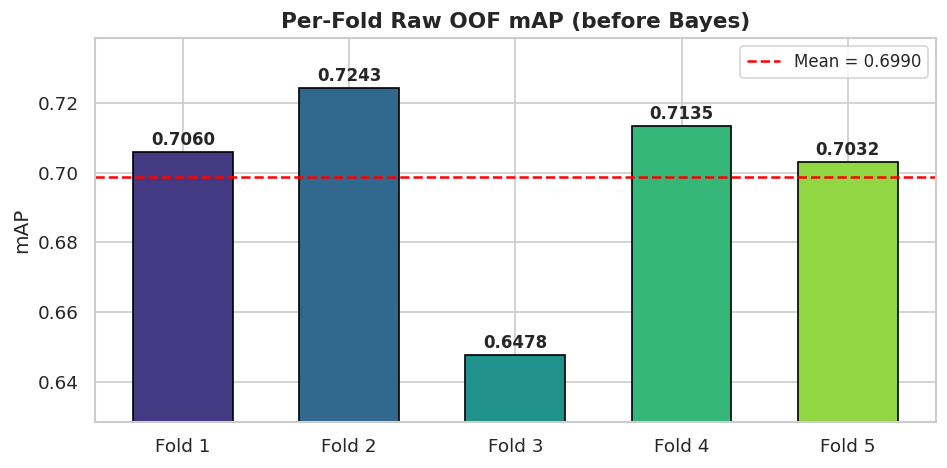

Raw OOF mAP: 0.6990 ± 0.0266


In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f"Fold {i+1}" for i in range(N_SPLITS)], fold_maps,
              color=sns.color_palette("viridis", N_SPLITS), edgecolor="black", width=0.6)
ax.axhline(np.mean(fold_maps), color="red", linestyle="--", linewidth=1.5,
           label=f"Mean = {np.mean(fold_maps):.4f}")
for bar, v in zip(bars, fold_maps):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Per-Fold Raw OOF mAP (before Bayes)", fontsize=13, fontweight="bold")
ax.set_ylabel("mAP")
ax.set_ylim(min(fold_maps)*0.97, max(fold_maps)*1.02)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("fold_map.png", bbox_inches="tight")
plt.show()
print(f"Raw OOF mAP: {np.mean(fold_maps):.4f} ± {np.std(fold_maps):.4f}")


## Bayesian Beta Grid Search

In [20]:
oof_mean=np.mean(np.stack(oof_raw,axis=0),axis=0)
print(f"\nRaw OOF mAP={macro_map(oof_mean):.4f}  logloss={mll(oof_mean):.4f}")

# ── Convenience: apply Bayes to mean OOF ──────────────────────────────────
def apply_bayes_oof(raw_proba, beta_size, beta_den, beta_mig, beta_ctx):
    out=np.zeros_like(raw_proba)
    for fs in fold_store:
        vli=fs["vli"]
        out[vli]=apply_bayes(
            raw_proba[vli],fs["Xva_p"],fs["Xva_ids"],
            fs["size_prior"],fs["dens_stats"],
            fs["global_prior"],fs["night_p"],fs["cell_p"],fs["cn_p"],
            fs["night_n"],fs["cell_n"],fs["cn_n"],
            beta_size=beta_size,beta_den=beta_den,beta_mig=beta_mig,beta_ctx=beta_ctx,
        )
    return out

base_oof=apply_bayes_oof(oof_mean,BETA_SIZECOND,BETA_DENSITY,BETA_NIGHTMIG,BETA_CTX)
base_map=macro_map(base_oof); base_ll=mll(base_oof)
print(f"Base Bayes OOF mAP={base_map:.4f}  logloss={base_ll:.4f}")

# ── v20: Optuna beta search (200 trials, continuous bounds) ────────────────
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    _OPTUNA_OK = True
except ImportError:
    _OPTUNA_OK = False
    print("WARNING: optuna not installed, falling back to grid search")

if _OPTUNA_OK:
    print(f"Searching Bayes betas (Optuna, {OPTUNA_N_TRIALS} trials)...")

    def _objective(trial):
        bs = trial.suggest_float("size", *BETA_BOUNDS["size"])
        bd = trial.suggest_float("den",  *BETA_BOUNDS["den"])
        bm = trial.suggest_float("mig",  *BETA_BOUNDS["mig"])
        bc = trial.suggest_float("ctx",  *BETA_BOUNDS["ctx"])
        o  = apply_bayes_oof(oof_mean, bs, bd, bm, bc)
        ll = mll(o)
        # Penalise if logloss degrades more than tolerance vs base
        if ll > base_ll + 0.003:
            return 0.0   # Optuna maximises — return 0 as "infeasible"
        return macro_map(o)

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    # Seed with v18 proven values
    study.enqueue_trial({"size": 0.20, "den": 0.10, "mig": 0.14, "ctx": 0.10})
    study.optimize(_objective, n_trials=OPTUNA_N_TRIALS, show_progress_bar=False)

    bp = study.best_params
    best_betas = (bp["size"], bp["den"], bp["mig"], bp["ctx"])
    best_map_b = study.best_value
    best_oof_b = apply_bayes_oof(oof_mean, *best_betas)
    best_ll_b  = mll(best_oof_b)
    print(f"Best betas (size,den,mig,ctx): ({best_betas[0]:.3f}, {best_betas[1]:.3f}, {best_betas[2]:.3f}, {best_betas[3]:.3f})")
    print(f"Bayes OOF mAP={best_map_b:.4f}  logloss={best_ll_b:.4f}")

else:
    # Fallback: same grid as v18
    grid_size=[0.12, 0.17, 0.22]
    grid_den =[0.06, 0.10, 0.14]
    grid_mig =[0.10, 0.14, 0.18]
    grid_ctx =[0.00, 0.08, 0.12]
    best_betas=(BETA_SIZECOND,BETA_DENSITY,BETA_NIGHTMIG,BETA_CTX)
    best_map_b,best_ll_b=base_map,base_ll
    print("Searching Bayes betas (grid fallback)...")
    for bs in grid_size:
        for bd in grid_den:
            for bm in grid_mig:
                for bc in grid_ctx:
                    o=apply_bayes_oof(oof_mean,bs,bd,bm,bc)
                    m=macro_map(o); ll=mll(o)
                    if (m>best_map_b+1e-6) and (ll<=base_ll+0.003):
                        best_betas=(bs,bd,bm,bc); best_map_b=m; best_ll_b=ll
    print(f"Best betas (size,den,mig,ctx): {best_betas}")
    print(f"Bayes OOF mAP={best_map_b:.4f}  logloss={best_ll_b:.4f}")

oof_bayes=[apply_bayes_oof(oof_raw[mi],*best_betas) for mi in range(M_MC)]
oof_bayes_mean=np.mean(np.stack(oof_bayes,axis=0),axis=0)



Raw OOF mAP=0.6756  logloss=0.7731
Base Bayes OOF mAP=0.6861  logloss=0.5937
Searching Bayes betas (Optuna, 200 trials)...
Best betas (size,den,mig,ctx): (0.231, 0.086, 0.063, 0.014)
Bayes OOF mAP=0.6877  logloss=0.5958


In [21]:
# ═══════════════════════════════════════════════════════════════════════
# v20: BINARY EXPERT BLEND — per-class alpha OOF-tuned
# v18 used fixed alpha=0.05 (from v17 logs with different architecture)
# v20: tune Corm alpha on Corm-AP, Wader alpha on Wader-AP independently
# This avoids macro-mAP averaging hiding minority class degradation
# ═══════════════════════════════════════════════════════════════════════

C_IDX = name2idx["Cormorants"]
W_IDX = name2idx["Waders"]
te_binary_corm = np.mean(np.stack(te_binary_corm_folds, axis=0), axis=0)
te_binary_wadr = np.mean(np.stack(te_binary_wadr_folds, axis=0), axis=0)

def blend_experts(mc, bc_prob, bw_prob, alpha_c, alpha_w):
    r = mc.copy()
    r[:, C_IDX] = (1-alpha_c)*mc[:, C_IDX] + alpha_c*bc_prob
    r[:, W_IDX] = (1-alpha_w)*mc[:, W_IDX] + alpha_w*bw_prob
    r /= np.clip(r.sum(axis=1, keepdims=True), EPS, None)
    return r

# Tune alpha_c independently on Cormorant AP
print("Tuning binary alpha per class...")
best_alpha_c, best_corm_ap = 0.05, -1.0
for a in BINARY_ALPHA_GRID:
    tmp = blend_experts(oof_bayes_mean, oof_binary_corm, oof_binary_wadr, a, 0.0)
    cap = per_class_ap(tmp)[C_IDX]
    print(f"  alpha_c={a:.2f} -> Corm AP={cap:.4f}")
    if cap > best_corm_ap:
        best_corm_ap = cap
        best_alpha_c = a

# Tune alpha_w independently on Wader AP
best_alpha_w, best_wadr_ap = 0.05, -1.0
for a in BINARY_ALPHA_GRID:
    tmp = blend_experts(oof_bayes_mean, oof_binary_corm, oof_binary_wadr, 0.0, a)
    wap = per_class_ap(tmp)[W_IDX]
    print(f"  alpha_w={a:.2f} -> Wader AP={wap:.4f}")
    if wap > best_wadr_ap:
        best_wadr_ap = wap
        best_alpha_w = a

print(f"\nSelected: alpha_c={best_alpha_c:.2f}  alpha_w={best_alpha_w:.2f}")

BINARY_BLEND_ALPHA_C = best_alpha_c
BINARY_BLEND_ALPHA_W = best_alpha_w

oof_bayes_mean = blend_experts(oof_bayes_mean, oof_binary_corm, oof_binary_wadr,
                                BINARY_BLEND_ALPHA_C, BINARY_BLEND_ALPHA_W)
oof_bayes = [blend_experts(oof_bayes[mi], oof_binary_corm, oof_binary_wadr,
                            BINARY_BLEND_ALPHA_C, BINARY_BLEND_ALPHA_W)
             for mi in range(M_MC)]

aps_blend = per_class_ap(oof_bayes_mean)
print(f"After binary blend (Corm alpha={BINARY_BLEND_ALPHA_C:.2f}, Wader alpha={BINARY_BLEND_ALPHA_W:.2f}):")
print(f"  Cormorant AP: {aps_blend[C_IDX]:.4f}  (v20=0.311, v18=0.316, v17=0.326)")
print(f"  Wader AP:     {aps_blend[W_IDX]:.4f}  (v20=0.447, v18=0.454)")
print(f"  macro-mAP:    {macro_map(oof_bayes_mean):.4f}")


Tuning binary alpha per class...
  alpha_c=0.02 -> Corm AP=0.3218
  alpha_c=0.05 -> Corm AP=0.3206
  alpha_c=0.08 -> Corm AP=0.3090
  alpha_c=0.12 -> Corm AP=0.3041
  alpha_c=0.15 -> Corm AP=0.3012
  alpha_c=0.20 -> Corm AP=0.2943
  alpha_c=0.25 -> Corm AP=0.2912
  alpha_c=0.30 -> Corm AP=0.2864
  alpha_w=0.02 -> Wader AP=0.4476
  alpha_w=0.05 -> Wader AP=0.4464
  alpha_w=0.08 -> Wader AP=0.4443
  alpha_w=0.12 -> Wader AP=0.4407
  alpha_w=0.15 -> Wader AP=0.4376
  alpha_w=0.20 -> Wader AP=0.4334
  alpha_w=0.25 -> Wader AP=0.4297
  alpha_w=0.30 -> Wader AP=0.4267

Selected: alpha_c=0.02  alpha_w=0.02
After binary blend (Corm alpha=0.02, Wader alpha=0.02):
  Cormorant AP: 0.3231  (v20=0.311, v18=0.316, v17=0.326)
  Wader AP:     0.4477  (v20=0.447, v18=0.454)
  macro-mAP:    0.6886


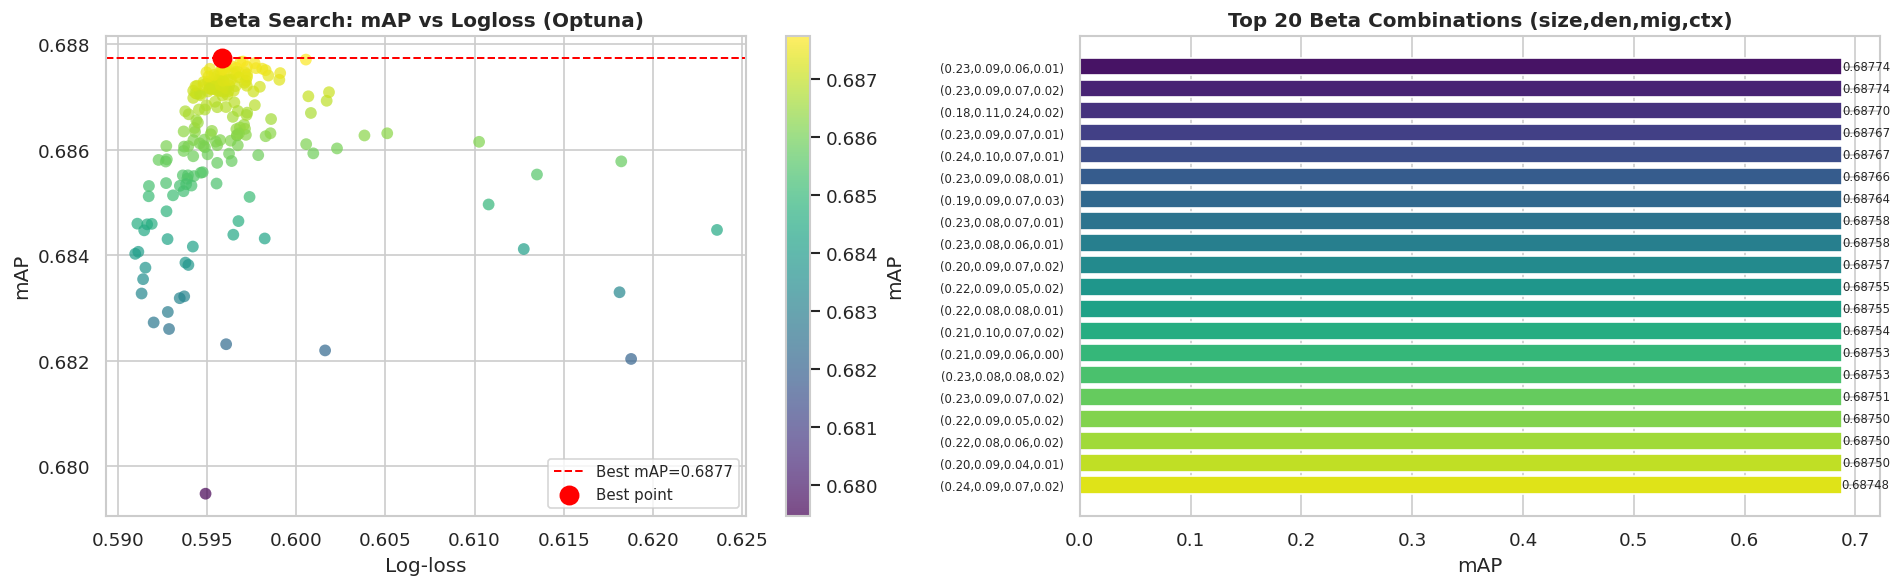

In [22]:
# Build gr_df from Optuna trials (or grid_results if fallback was used)
if _OPTUNA_OK:
    rows = []
    for t in study.trials:
        if t.state.name == "COMPLETE" and t.params:
            p = t.params
            o = apply_bayes_oof(oof_mean, p["size"], p["den"], p["mig"], p["ctx"])
            rows.append((p["size"], p["den"], p["mig"], p["ctx"], macro_map(o), mll(o)))
    gr_df = pd.DataFrame(rows, columns=["beta_size","beta_den","beta_mig","beta_ctx","mAP","logloss"])
else:
    gr_df = pd.DataFrame(grid_results, columns=["beta_size","beta_den","beta_mig","beta_ctx","mAP","logloss"])

top20 = gr_df.nlargest(20, "mAP")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sc = axes[0].scatter(gr_df["logloss"], gr_df["mAP"],
                     c=gr_df["mAP"], cmap="viridis", alpha=0.7, s=50, edgecolor="none")
axes[0].axhline(best_map_b, color="red", linestyle="--", linewidth=1.2, label=f"Best mAP={best_map_b:.4f}")
best_row = gr_df.loc[gr_df["mAP"] == gr_df["mAP"].max()]
if len(best_row):
    axes[0].scatter(best_row["logloss"].values[0], best_row["mAP"].values[0],
                    color="red", s=120, zorder=5, label="Best point")
axes[0].set_xlabel("Log-loss"); axes[0].set_ylabel("mAP")
axes[0].set_title("Beta Search: mAP vs Logloss (Optuna)", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)
plt.colorbar(sc, ax=axes[0], label="mAP")

labels = [f"({r.beta_size:.2f},{r.beta_den:.2f},{r.beta_mig:.2f},{r.beta_ctx:.2f})" for r in top20.itertuples()]
axes[1].barh(range(len(top20)), top20["mAP"].values,
             color=sns.color_palette("viridis", len(top20)), edgecolor="white")
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(labels, fontsize=7)
axes[1].set_xlabel("mAP")
axes[1].set_title("Top 20 Beta Combinations (size,den,mig,ctx)", fontsize=12, fontweight="bold")
axes[1].invert_yaxis()
for i, v in enumerate(top20["mAP"].values):
    axes[1].text(v+0.0002, i, f"{v:.5f}", va="center", fontsize=7)

plt.tight_layout()
plt.savefig("beta_grid_search.png", bbox_inches="tight")
plt.show()


## Bias Tuning on Weakest Classes

Weakest 3 classes: ['Cormorants', 'Waders', 'Geese']
Their APs: [0.3231, 0.4477, 0.6013]
  [1] Cormorants            AP=0.3231  best_bias=+0.30 (wide±0.30)
  [2] Waders                AP=0.4477  best_bias=+0.00 (std±0.15)
  [3] Geese                 AP=0.6013  best_bias=-0.10 (std±0.15)

Bias applied: {'Cormorants': 0.3, 'Geese': -0.1}


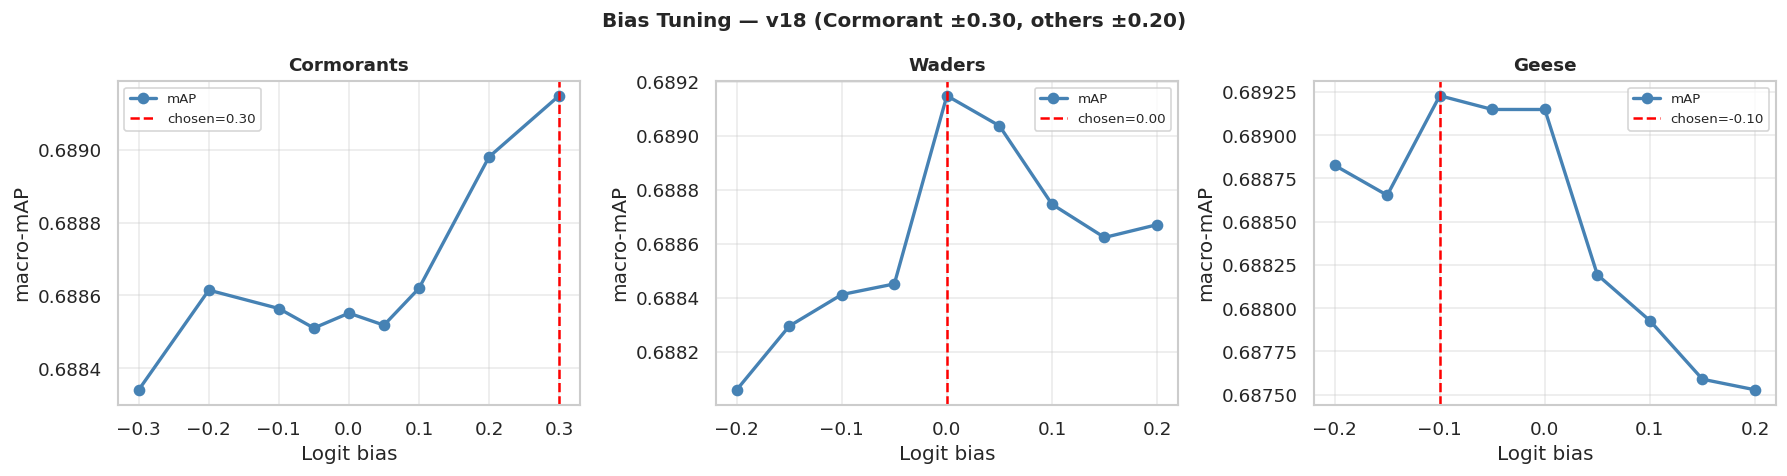

In [23]:
aps=per_class_ap(oof_bayes_mean)
weak=np.argsort(aps)[:WEAKEST_K]
print(f"Weakest {WEAKEST_K} classes: {[CLASSES[i] for i in weak]}")
print(f"Their APs: {[round(float(aps[i]),4) for i in weak]}")

bias=np.zeros(C,dtype=float)
base_ll_b=mll(oof_bayes_mean); base_m_b=macro_map(oof_bayes_mean)
bias_history=[]

for rank, c in enumerate(weak):
    best_b=0.0; best_m_local=base_m_b
    # Rank-0 (weakest = Cormorants): wider grid ±0.30 for more correction room
    # Rank 1-2: standard v10 grid ±0.15
    grid = BIAS_GRID_WIDE if rank == 0 else BIAS_GRID
    grid_label = "wide±0.30" if rank == 0 else "std±0.15"
    for b in grid:
        cand=bias.copy(); cand[c]=b
        o=apply_logit_bias(oof_bayes_mean,cand)
        m=macro_map(o); ll=mll(o)
        bias_history.append({"class":CLASSES[c],"bias":b,"mAP":m,"logloss":ll})
        if (m>best_m_local+1e-6) and (ll<=base_ll_b+BIAS_LL_TOL):
            best_m_local=m; best_b=b
    bias[c]=best_b
    print(f"  [{rank+1}] {CLASSES[c]:20s}  AP={aps[c]:.4f}  best_bias={best_b:+.2f} ({grid_label})")

print("\nBias applied:",{CLASSES[i]:round(float(bias[i]),3) for i in range(C) if abs(bias[i])>1e-9})

bh = pd.DataFrame(bias_history)
fig, axes = plt.subplots(1, WEAKEST_K, figsize=(5*WEAKEST_K, 4), sharey=False)
if WEAKEST_K == 1: axes = [axes]
for ax, c in zip(axes, weak):
    sub = bh[bh["class"]==CLASSES[c]]
    ax.plot(sub["bias"], sub["mAP"], marker="o", color="steelblue", linewidth=2, label="mAP")
    ax.axvline(bias[c], color="red", linestyle="--", linewidth=1.5, label=f"chosen={bias[c]:.2f}")
    ax.set_title(f"{CLASSES[c]}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Logit bias"); ax.set_ylabel("macro-mAP")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
plt.suptitle("Bias Tuning — v18 (Cormorant ±0.30, others ±0.20)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("bias_tuning.png", bbox_inches="tight")
plt.show()

oof_final=[final_normalize(apply_logit_bias(oof_bayes[mi],bias)) for mi in range(M_MC)]
oof_final_mean=np.mean(np.stack(oof_final,axis=0),axis=0)


## OOF Final Diagnostics


DIAGNOSTICS: OOF FINAL ENSEMBLE v21  |  macro-mAP=0.6882  logloss=0.6025


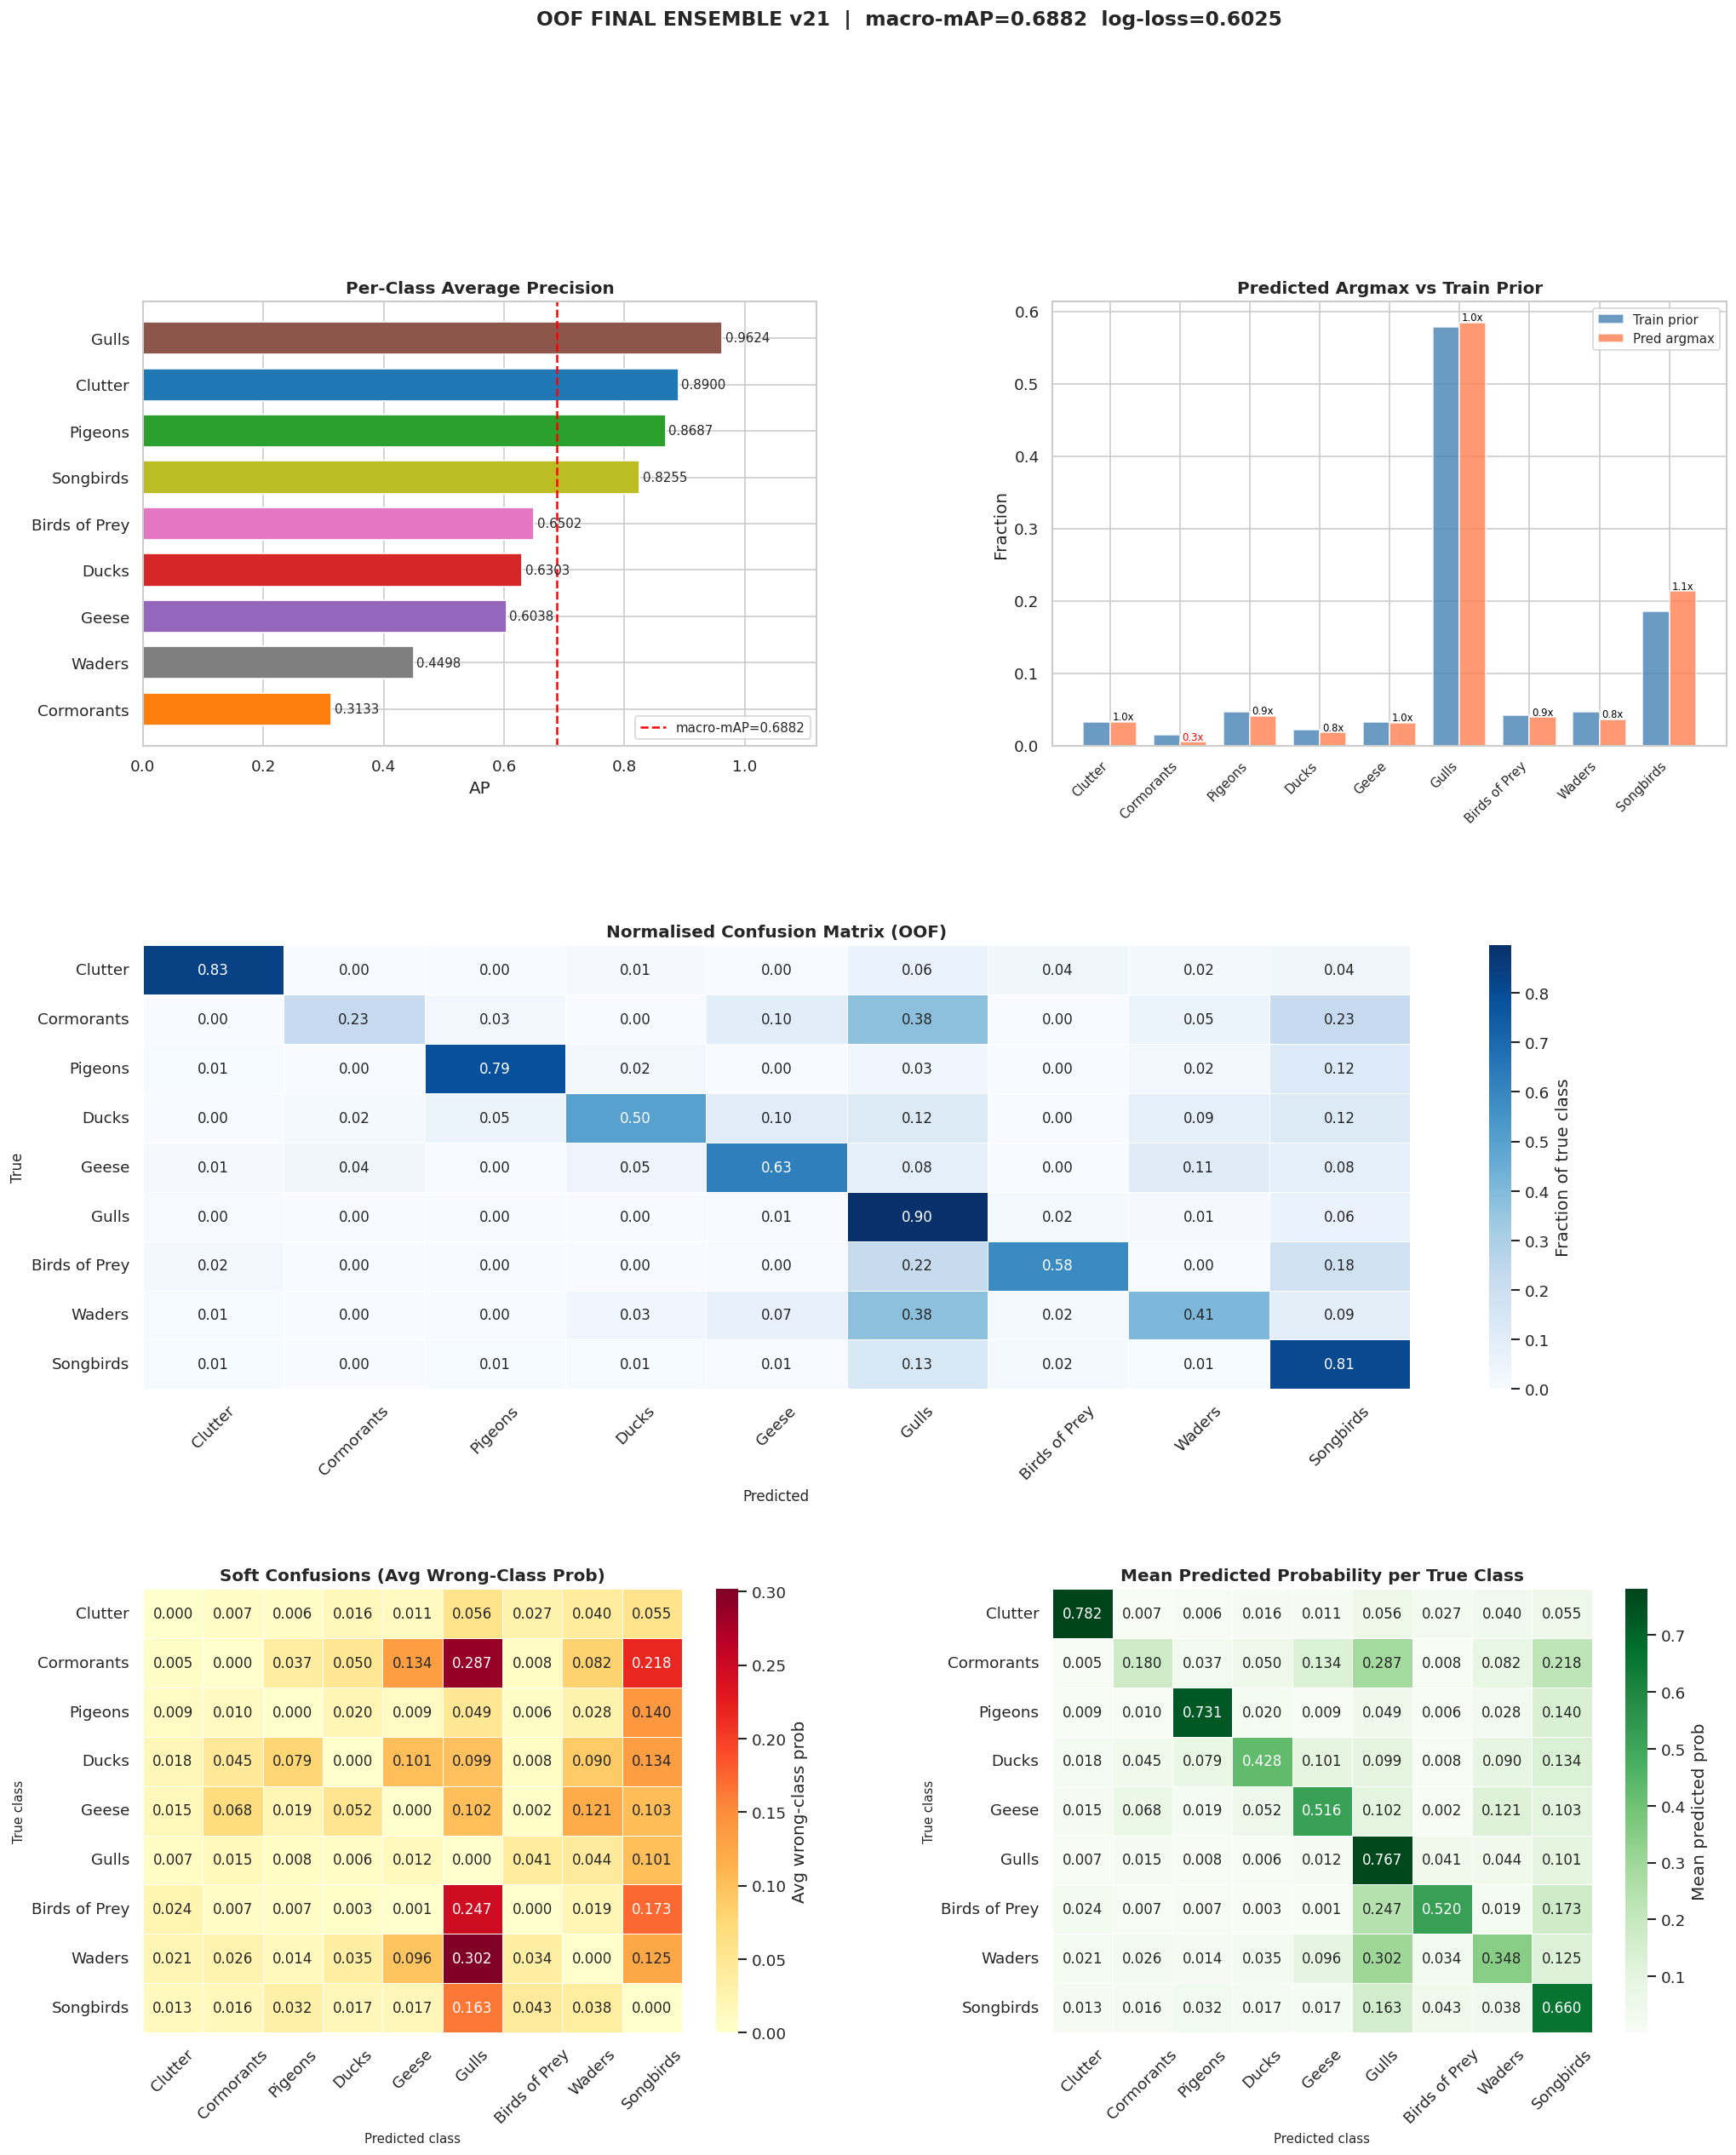


PER-CLASS AP (text):
  Clutter               0.8900  ███████████████████████████████████
  Cormorants            0.3133  ████████████
  Pigeons               0.8687  ██████████████████████████████████
  Ducks                 0.6303  █████████████████████████
  Geese                 0.6038  ████████████████████████
  Gulls                 0.9624  ██████████████████████████████████████
  Birds of Prey         0.6502  ██████████████████████████
  Waders                0.4498  █████████████████
  Songbirds             0.8255  █████████████████████████████████

TOP-10 HARD CONFUSIONS:
  Gulls                  -> Songbirds               (93)
  Songbirds              -> Gulls                   (65)
  Waders                 -> Gulls                   (45)
  Gulls                  -> Birds of Prey           (26)
  Birds of Prey          -> Gulls                   (24)
  Birds of Prey          -> Songbirds               (19)
  Gulls                  -> Waders                  (19)
  Cormorants 

In [24]:
print_diagnostics(oof_final_mean, "OOF FINAL ENSEMBLE v21")

aps_f = per_class_ap(oof_final_mean)
C_IDX = name2idx["Cormorants"]
W_IDX = name2idx["Waders"]

print(f"\n{'='*62}")
print(f"V20 PER-CLASS AP (target ≥ 0.60):")
for i, cls in enumerate(CLASSES):
    flag = "✓" if aps_f[i] >= 0.60 else ("→ CLOSE" if aps_f[i] >= 0.50 else "✗")
    print(f"  {cls:20s}: {aps_f[i]:.4f}  {flag}")
print(f"{'='*62}")
print(f"macro-mAP:  {macro_map(oof_final_mean):.4f}")
print(f"Bottom-3:   {np.sort(aps_f)[:3].mean():.4f}")
print(f"Cormorant: {aps_f[C_IDX]:.4f}  (v18=0.316, v17=0.326, target=0.60)")
print(f"Wader:     {aps_f[W_IDX]:.4f}  (v17=0.448,              target=0.60)")
print(f"\nv18 improvements expected:")
print(f"  Gull-undersampled models → better Cormorant/Wader separation")
print(f"  BIAS_GRID_WIDE fix → bias cell no longer crashes")


## Test Predictions

Blending binary experts into test predictions...
  Cormorant alpha=0.02  Wader alpha=0.02


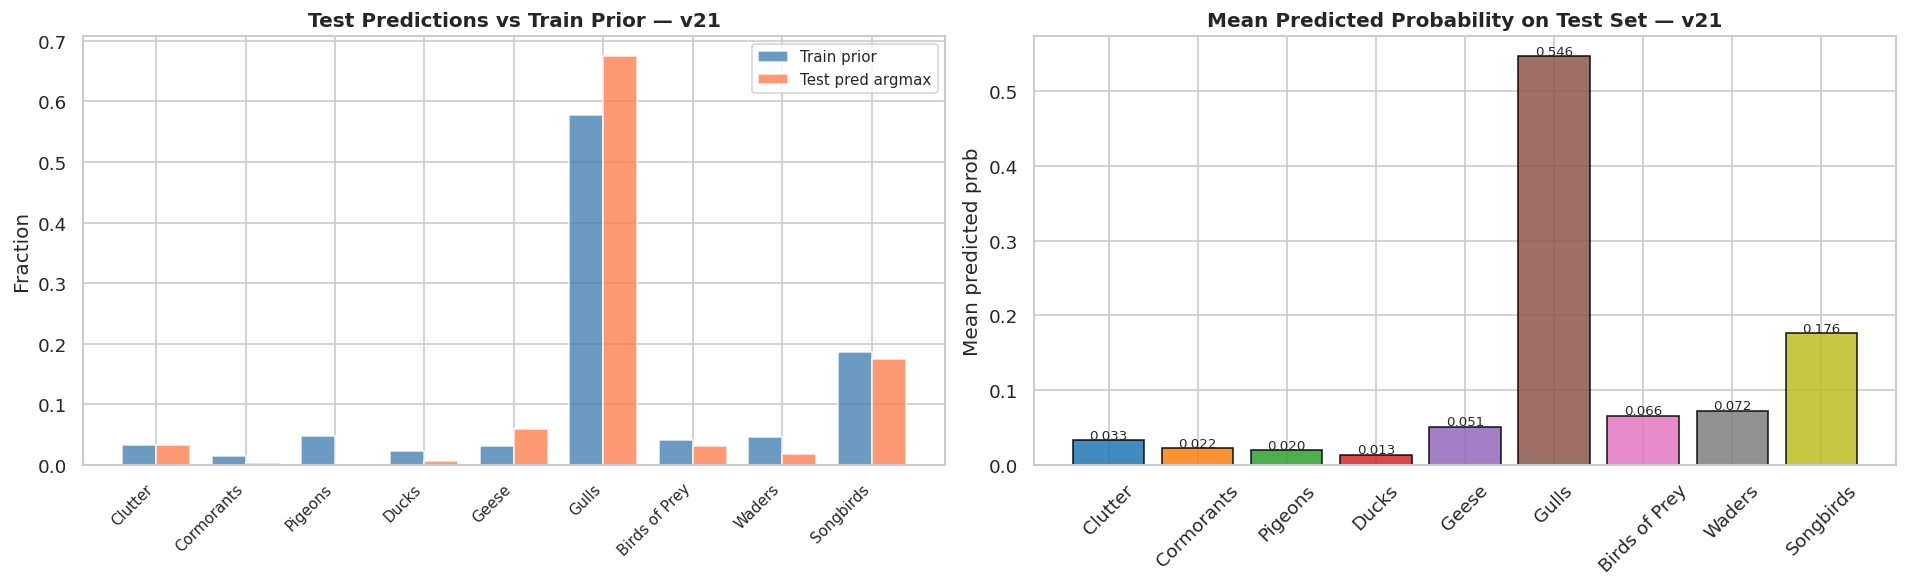


Test argmax distribution:
  Clutter             :    61  (3.3%)  prior=3.2%
  Cormorants          :     5  (0.3%)  prior=1.5%
  Pigeons             :     4  (0.2%)  prior=4.7%
  Ducks               :    11  (0.6%)  prior=2.2%
  Geese               :   112  (6.0%)  prior=3.2%
  Gulls               :  1262  (67.4%)  prior=57.8%
  Birds of Prey       :    58  (3.1%)  prior=4.2%
  Waders              :    32  (1.7%)  prior=4.6%
  Songbirds           :   327  (17.5%)  prior=18.6%


In [25]:
test_preds=[np.zeros((len(X_test),C),dtype=float) for _ in range(M_MC)]
for fs in fold_store:
    for mi in range(M_MC):
        te_raw=fs["te_raws"][mi]
        te_b=apply_bayes(
            te_raw,fs["Xte_p"],fs["Xte_ids"],
            fs["size_prior"],fs["dens_stats"],
            fs["global_prior"],fs["night_p"],fs["cell_p"],fs["cn_p"],
            fs["night_n"],fs["cell_n"],fs["cn_n"],
            beta_size=best_betas[0],beta_den=best_betas[1],
            beta_mig=best_betas[2],beta_ctx=best_betas[3],
        )
        te_f=final_normalize(apply_logit_bias(te_b,bias))
        test_preds[mi]+=te_f/N_SPLITS

test_pred=final_normalize(np.mean(np.stack(test_preds,axis=0),axis=0))

# ── v20: blend binary experts into test (per-class alphas) ──────────────────
print(f"Blending binary experts into test predictions...")
print(f"  Cormorant alpha={BINARY_BLEND_ALPHA_C:.2f}  Wader alpha={BINARY_BLEND_ALPHA_W:.2f}")
test_pred = blend_experts(test_pred, te_binary_corm, te_binary_wadr,
                          BINARY_BLEND_ALPHA_C, BINARY_BLEND_ALPHA_W)
test_pred = final_normalize(test_pred)
am_test=test_pred.argmax(axis=1)
pred_test_fracs = np.array([(am_test==i).mean() for i in range(C)])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x_pos = np.arange(C); w = 0.38
axes[0].bar(x_pos - w/2, TRAIN_PRIOR, width=w, label="Train prior",
            color="steelblue", alpha=0.8, edgecolor="white")
axes[0].bar(x_pos + w/2, pred_test_fracs, width=w, label="Test pred argmax",
            color="coral", alpha=0.8, edgecolor="white")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(CLASSES, rotation=45, ha="right", fontsize=9)
axes[0].set_title("Test Predictions vs Train Prior — v21", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Fraction"); axes[0].legend(fontsize=9)

mean_test_proba = test_pred.mean(axis=0)
axes[1].bar(CLASSES, mean_test_proba,
            color=sns.color_palette("tab10", C), edgecolor="black", alpha=0.85)
axes[1].set_title("Mean Predicted Probability on Test Set — v21", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Mean predicted prob")
axes[1].tick_params(axis="x", rotation=45)
for i, v in enumerate(mean_test_proba):
    axes[1].text(i, v+0.002, f"{v:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("test_distribution_v21.png", bbox_inches="tight")
plt.show()

print("\nTest argmax distribution:")
for i,c in enumerate(CLASSES):
    cnt=(am_test==i).sum()
    print(f"  {c:20s}: {cnt:5d}  ({100*cnt/len(am_test):.1f}%)  prior={100*TRAIN_PRIOR[i]:.1f}%")


## Generate Submission

In [26]:
sub=pd.DataFrame({"track_id":test["track_id"].astype(str).values})
out_cols=list(sample.columns[1:]) if len(sample.columns)>1 else CLASSES

def normalize_col(s): return s.lower().replace(" ","_").replace("-","_")
norm2idx={normalize_col(c):i for c,i in name2idx.items()}

for col in out_cols:
    col_norm=normalize_col(col)
    if col_norm in norm2idx:
        sub[col]=test_pred[:,norm2idx[col_norm]]
    else:
        best_cls=max(CLASSES,key=lambda c:sum(a==b for a,b in zip(normalize_col(c),col_norm)))
        print(f"WARNING: col '{col}' fallback matched to '{best_cls}'")
        sub[col]=test_pred[:,name2idx[best_cls]]

assert not sub.isna().any().any(),"NaN in submission!"
rs=sub[out_cols].sum(axis=1)
print(f"Row-sum min={rs.min():.6f} mean={rs.mean():.6f} max={rs.max():.6f}")
sub.to_csv("submission.csv",index=False)
print("✓ Saved submission.csv")
display(sub.head(5))


Row-sum min=1.000000 mean=1.000000 max=1.000000
✓ Saved submission.csv


,track_id,Clutter,Cormorants,Pigeons,Ducks,Geese,Gulls,Birds of Prey,Waders,Songbirds
0,6868504,0.020731,0.015351,0.100387,0.084496,0.517203,0.133039,0.000797,0.080738,0.047258
1,6868536,0.021817,0.014568,0.107727,0.083540,0.466562,0.113664,0.000725,0.116193,0.075203
2,6868565,0.025540,0.026539,0.054665,0.038102,0.666546,0.116762,0.000750,0.048008,0.023088
3,6868861,0.002778,0.068355,0.008607,0.017068,0.827134,0.030811,0.000384,0.035952,0.008911
4,6869275,0.000716,0.057950,0.007664,0.007865,0.815394,0.058628,0.000551,0.041348,0.009883


##  Next Steps / Ideas for Improvement

| Direction | Detail |
|-----------|--------|
| **v20 target** | Corm AP ≥ 0.60, Wader AP ≥ 0.60, LB ≥ 0.60 |
| **If Corm still low** | Try pos/neg ratio=1 for binary; or add a 3rd CB variant focused on Corm |
| **If Wader still low** | Wader is confused with Gulls (43-45 cases); feature: altitude band tightness |
| **If LB gap persists** | The OOF→LB gap (~0.13) suggests distribution shift; try TTA or test-time prior matching |
| **Ensemble v18+v20** | Geometric mean of v18 and v20 test predictions (avg log-probs) |
| **Sequence models** | LSTM/Transformer on trajectory — currently only aggregate features |
